# Loans at Risk: Capturing Default - EXPLORATORY DATA ANALYSIS

## Objective
This notebook examines the feature space produced during the ETL stage in order to understand how borrower characteristics relate to loan default risk. The purpose is not simply to inspect variable distributions, but to evaluate whether the information available at the time a borrower submits a loan application contains meaningful signals for predicting repayment outcomes.

The analysis operates within the **application-submission prediction boundary** established earlier in the pipeline. Only information observable when the borrower applied for the loan is used for modeling. During ETL the dataset was organized into two layers. The **clean dataset** preserves the normalized loan records and retains additional variables that describe the full loan lifecycle. The **feature base dataset** contains the subset of variables that respect the application-time information boundary and therefore form the modeling feature space.

This separation allows diagnostic validation to use the full loan record while ensuring that predictive modeling relies only on information that would have been available at the moment of application. The analysis in this notebook therefore examines the structure of the dataset and evaluates whether the variables within the modeling boundary plausibly capture mechanisms relevant to credit risk.

---

## Analytical Structure
The analysis is organized in two stages corresponding to the dataset layers produced during the ETL notebook.

1. **Diagnostic validation using the clean dataset**  
2. **Decision-focused analysis using the feature base dataset**

The first stage verifies that the dataset behaves coherently from a lending perspective. Loan outcomes must follow a plausible repayment structure, the temporal ordering of the dataset must reflect the development of lending cohorts over time, and the modeling population must be clearly defined. Before any modeling work begins, the dataset itself must demonstrate that it represents a valid observation of the lending process.

The second stage examines the variables that remain within the modeling boundary and evaluates whether they contain meaningful signals for predicting loan default. The focus here is analytical rather than technical: the objective is to understand how borrower characteristics, loan terms, and credit behavior relate to repayment outcomes and whether those relationships appear stable enough to support modeling.

Taken together, these two stages move from **dataset integrity** to **risk signal investigation**, establishing both the validity of the data and the analytical basis for the modeling phase that follows.

---

## Notebook Structure

### Part 1 — Diagnostic Validation (`clean`)
The first stage evaluates the structural integrity of the dataset using the **clean training dataset** and **clean testing dataset**. The objective is to confirm that the outcome variable, temporal structure, and dataset composition behave as expected before any modeling analysis is performed.

Loan datasets contain a mixture of completed and ongoing repayment states. For modeling purposes the analysis must focus on outcomes that represent the completed repayment process. This stage therefore verifies that the loan status variable provides a coherent representation of repayment outcomes and that the modeling cohort can be defined in a way that reflects final borrower behavior.

In addition to validating outcome definitions, this stage examines the temporal structure of the dataset. Lending platforms evolve over time, loan volumes change across years, and reporting practices may shift. Confirming the temporal structure ensures that the modeling phase trains on earlier lending cohorts and evaluates performance on a later period.

This stage defines the modeling population by excluding loans whose repayment outcome has not yet been determined. Once the modeling cohort is established, the analysis proceeds to examine the submission-time features available at loan application.

### Part 2 — Decision EDA (`feature_base`)
The second stage analyzes the feature space used for modeling. The analysis focuses exclusively on variables contained in the **feature base training dataset** and **feature base testing dataset**, which include only information available at application submission.

To keep the analysis interpretable, variables are examined in groups that reflect the types of information available when a borrower applies for a loan:


1. **Target Definition & Cohort**
2. **Application Profile**
3. **Loan Structure**
4. **Debt Burden**
5. **Credit History**
6. **Recent Credit Behavior**
7. **Reporting Shifts / Data Quality**

These domains organize the variables according to the type of information they represent. Application profile variables describe the borrower’s financial situation at the moment of application. Loan structure variables describe the contractual terms of the loan itself. Debt burden measures the borrower’s leverage relative to income and available credit. Credit history and recent credit behavior summarize how the borrower has managed credit obligations in the past. Reporting shifts and data quality are examined separately to identify structural artifacts that could affect modeling.


In [1]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()
project_root = None

for parent_path in (current_path, *current_path.parents):
    if (parent_path / "pyproject.toml").exists():
        project_root = parent_path
        break

if project_root is None:
    raise RuntimeError(
        f"Failed to resolve project root: pyproject.toml not found from {current_path}"
    )

src_path = project_root / "src"
if not src_path.exists():
    raise RuntimeError(f"Expected 'src' directory at: {src_path}")

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

{
    "stage": "bootstrap_import_path_ready",
    "project_root": str(project_root),
}

{'stage': 'bootstrap_import_path_ready',
 'project_root': 'D:\\Portfolio\\loans-at-risk-capturing-default'}

In [ ]:
# ============================================================================
# Imports: libraries and custom functions
# ============================================================================

from datetime import datetime, timezone
from typing import Callable
import uuid
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython.display import HTML
from ipywidgets import HBox, VBox, Output, Layout

# Custom functions
from config.logging import (
    log_messages,
    get_logger
)
from analysis.eda import (
    build_terminal_cohort,
)

In [ ]:
# ===============================
# Paths and run context
# ===============================

logs_root = project_root / "logs"
logs_root.mkdir(parents=True, exist_ok=True)

PROJECT_LOG_FILE = logs_root / "project.log"

run_id = uuid.uuid4().hex[:10]
run_timestamp_utc = datetime.now(timezone.utc)

run_header = (
    "NEW RUN: "
    f"{run_timestamp_utc.strftime('%Y-%m-%d %H:%M:%S')} UTC | "
    f"RUN_ID={run_id}"
)

log_messages("\n" + "=" * 60, PROJECT_LOG_FILE)
log_messages(run_header, PROJECT_LOG_FILE)
log_messages("=" * 60 + "\n", PROJECT_LOG_FILE)

log: Callable[[str], None] = get_logger(PROJECT_LOG_FILE)
log("EDA notebook initialized")
log(f"project_root: {project_root}")

log(run_header)

{
    "stage": "run_started",
    "run_id": run_id,
    "utc_timestamp": run_timestamp_utc.isoformat(),
}


# ---------------------------------------------------------------
# Inputs for this notebook (interim, report)
# ---------------------------------------------------------------

clean_train_data_file = project_root / "data" / "interim" / "clean_loan_data_2007_2014.parquet"
clean_test_data_file = project_root / "data" / "interim" / "clean_loan_data_2015.parquet"

feature_base_train_data_file = project_root / "data" / "interim" / "feature_base_loan_data_2007_2014.parquet"
feature_base_test_data_file = project_root / "data" / "interim" / "feature_base_loan_data_2015.parquet"

audit_dir = project_root / "artifacts" / "audit"

appendix_base_name = "appendix_A_clean_feature_universe"

appendix_parquet_file = audit_dir / f"{appendix_base_name}.parquet"
appendix_csv_file = audit_dir / f"{appendix_base_name}.csv"

required_directories = {
    clean_train_data_file.parent,
    clean_test_data_file.parent,
    feature_base_train_data_file.parent,
    feature_base_test_data_file.parent,
    appendix_parquet_file.parent,
    appendix_csv_file.parent,
}

for directory_path in sorted(required_directories):
    directory_path.mkdir(parents=True, exist_ok=True)

log(f"Clean training parquet path: {clean_train_data_file}")
log(f"Clean test parquet path: {clean_test_data_file}")
log(f"Feature base training parquet path: {feature_base_train_data_file}")
log(f"Feature base test parquet path: {feature_base_test_data_file}")
log(f"Appendix parquet path: {appendix_parquet_file}")
log(f"Appendix CSV path: {appendix_csv_file}")

## Part 1 — Diagnostic Validation (`clean`)

This section evaluates the structural integrity of the dataset using the **clean training dataset** and **clean testing dataset**. The objective is to confirm that the outcome variable, cohort definition, and temporal structure behave coherently before any feature-level analysis begins. Because the clean dataset retains the full loan record, it provides the appropriate layer for validating repayment outcomes and defining the modeling population.

---

#### 1.1 Label integrity and outcome distribution

The analysis begins by inspecting the normalized `loan_status` categories in order to confirm that repayment outcomes are represented consistently across the dataset. The distribution of outcomes is examined separately for the training (2007–2014) and testing (2015) periods to evaluate class balance and identify potential temporal shifts in outcome composition.

Understanding the outcome distribution is necessary before defining the modeling cohort, as changes in outcome composition across time can reflect both economic conditions and platform growth.

---

#### 1.2 Cohort definition

Loan datasets contain a mixture of completed and ongoing repayment states. For modeling purposes the population must be restricted to loans whose repayment outcomes are known.

This step evaluates whether a binary realized-outcome cohort can be constructed and determines how non-terminal loan states should be treated. The result is the definition of the modeling population used in the subsequent feature analysis.

---

#### 1.3 Temporal outcome dynamics

Repayment behavior is examined across issuance years in order to understand how default rates evolve over time. Default rates are computed by year and compared with issuance volume to distinguish changes in borrower outcomes from changes in platform scale.

This step helps identify maturation effects, structural breaks, or shifts in lending conditions that may influence how earlier lending cohorts relate to later ones.

---

#### 1.4 Missingness and reporting stability

Temporal missingness patterns are examined for variables known to exhibit reporting inconsistencies, particularly balance-related fields. The objective is to determine whether missing values reflect borrower characteristics or changes in reporting practices across time.

Identifying reporting shifts at this stage helps prevent structural artifacts from being misinterpreted as predictive signals during feature analysis.

---

#### 1.5 Structural boundary confirmation

Because the clean dataset retains variables describing the full loan lifecycle, this step verifies the separation between submission-time features and post-submission information. The objective is to confirm that repayment outcomes and cashflow variables behave coherently while remaining outside the modeling feature space.

This ensures that the modeling boundary defined during ETL is respected before proceeding to feature-level analysis.

---

#### 1.6 Diagnostic summary

This section summarizes the findings from the diagnostic validation and formalizes the modeling cohort used in Part 2. Once the population of loans with realized repayment outcomes has been confirmed, the analysis proceeds to examine the submission-time features contained in the feature base dataset.

In [ ]:
# Loading the dataframes for EDA Part 1.
df_clean_train = pd.read_parquet(clean_train_data_file)
log("Clean training dataset loaded")

df_clean_test = pd.read_parquet(clean_test_data_file)
log("Clean testing dataset loaded")

train_shape = (int(df_clean_train.shape[0]), int(df_clean_train.shape[1]))
test_shape = (int(df_clean_test.shape[0]), int(df_clean_test.shape[1]))

{
	"train_rows_and_columns": train_shape,
	"test_rows_and_columns": test_shape,
}

{'train_rows_and_columns': (466285, 51), 'test_rows_and_columns': (421094, 51)}

In [5]:
# -------------------------------
# Add issue_year for vintage diagnostics (train + test)
# -------------------------------

df_clean_train_with_year = df_clean_train.copy()
df_clean_test_with_year = df_clean_test.copy()

df_clean_train_with_year["issue_year"] = (
    pd.to_datetime(
        df_clean_train_with_year["issue_d"],
        errors="coerce"
    ).dt.year
)

df_clean_test_with_year["issue_year"] = (
    pd.to_datetime(
        df_clean_test_with_year["issue_d"],
        errors="coerce"
    ).dt.year
)


In [6]:
# -------------------------------
# Loan status by vintage (train)
# -------------------------------

year_status_table_train = pd.crosstab(
    df_clean_train_with_year["issue_year"],
    df_clean_train_with_year["loan_status"],
    dropna=False
)

year_status_table_train


loan_status,charged_off,current,default,does_not_meet_the_credit_policy._status:charged_off,does_not_meet_the_credit_policy._status:fully_paid,fully_paid,in_grace_period,issued,late_(16-30_days),late_(31-120_days)
issue_year,,,,,,,,,,
2007,45,0,0,113,239,206,0,0,0,0
2008,247,0,0,249,582,1315,0,0,0,0
2009,594,0,0,129,436,4122,0,0,0,0
2010,1483,7,1,270,731,10038,0,0,2,5
2011,3205,1953,8,0,0,16470,28,0,11,46
2012,8084,3444,28,0,0,41479,83,0,27,222
2013,14836,60264,182,0,0,56396,977,0,320,1780
2014,13981,158558,613,0,0,54713,2058,0,858,4847


In [7]:
# -------------------------------
# Loan status by vintage (test)
# -------------------------------

year_status_table_test = pd.crosstab(
    df_clean_test_with_year["issue_year"],
    df_clean_test_with_year["loan_status"],
    dropna=False
)

year_status_table_test


loan_status,charged_off,current,default,does_not_meet_the_credit_policy._status:charged_off,does_not_meet_the_credit_policy._status:fully_paid,fully_paid,in_grace_period,issued,late_(16-30_days),late_(31-120_days)
issue_year,,,,,,,,,,
2015,2773,377553,387,0,0,22984,3107,8460,1139,4691


#### Outcome distribution by vintage

Outcome composition varies materially across issuance years.

- Early vintages (2007–2012) are predominantly composed of terminal outcomes, reflecting full maturation.
- Later vintages (2013–2014) exhibit a high concentration of non-terminal loans (`current`, `late`), driven by incomplete outcome realization.
- The 2015 split is heavily censored and contains a substantial share of ongoing loans.

These patterns indicate that aggregate class balance must be interpreted in a temporal context. Apparent dominance of `current` status is attributable to maturation dynamics rather than label inconsistency.

Moving forward, realized-outcome restriction is required to ensure label certainty and avoid censoring bias.

In [8]:
# -------------------------------
# Terminal cohort definition (realized outcomes only)
# -------------------------------

terminal_statuses_final = [
    "fully_paid",
    "charged_off",
    "default",
    "does_not_meet_the_credit_policy._status:charged_off",
    "does_not_meet_the_credit_policy._status:fully_paid",
]

positive_statuses = [
    "charged_off",
    "default",
    "does_not_meet_the_credit_policy._status:charged_off",
]


In [9]:
# -------------------------------
# Build terminal cohort with binary target (train + test)
# -------------------------------

df_clean_train_terminal = build_terminal_cohort(
    df_clean_train_with_year,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log_file=str(project_log_file),
)

df_clean_test_terminal = build_terminal_cohort(
    df_clean_test_with_year,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log_file=str(project_log_file),
)


In [10]:
# -------------------------------
# Terminal cohort summary (train)
# -------------------------------

terminal_distribution_train = (
    df_clean_train_terminal["loan_status"]
    .value_counts(dropna=False)
    .to_frame(name="count")
)

terminal_distribution_train["percentage"] = (
    terminal_distribution_train["count"]
    / terminal_distribution_train["count"].sum()
    * 100
).round(2)

default_rate_train_percent = round(
    float(df_clean_train_terminal["target_default"].mean() * 100),
    2
)

terminal_distribution_train.loc["__default_rate_percent__"] = {
    "count": int(df_clean_train_terminal["target_default"].sum()),
    "percentage": default_rate_train_percent,
}

display(terminal_distribution_train)

# -------------------------------
# Terminal cohort summary (test)
# -------------------------------

terminal_distribution_test = (
    df_clean_test_terminal["loan_status"]
    .value_counts(dropna=False)
    .to_frame(name="count")
)

terminal_distribution_test["percentage"] = (
    terminal_distribution_test["count"]
    / terminal_distribution_test["count"].sum()
    * 100
).round(2)

default_rate_test_percent = round(
    float(df_clean_test_terminal["target_default"].mean() * 100),
    2
)

terminal_distribution_test.loc["__default_rate_percent__"] = {
    "count": int(df_clean_test_terminal["target_default"].sum()),
    "percentage": default_rate_test_percent,
}

display(terminal_distribution_test)


,count,percentage
loan_status,,
fully_paid,184739,80.04
charged_off,42475,18.40
does_not_meet_the_credit_policy._status:fully_paid,1988,0.86
default,832,0.36
does_not_meet_the_credit_policy._status:charged_off,761,0.33
current,0,0.00
in_grace_period,0,0.00
issued,0,0.00
late_(16-30_days),0,0.00


,count,percentage
loan_status,,
fully_paid,22984,87.91
charged_off,2773,10.61
default,387,1.48
current,0,0.00
does_not_meet_the_credit_policy._status:charged_off,0,0.00
does_not_meet_the_credit_policy._status:fully_paid,0,0.00
in_grace_period,0,0.00
issued,0,0.00
late_(16-30_days),0,0.00


#### Realized-outcome cohort definition

Restricting the dataset to terminal outcomes produces a stable and interpretable binary modeling cohort.

- Non-terminal statuses (`current`, `late`, `in_grace_period`, `issued`) are excluded to eliminate censoring risk.
- Policy-flagged terminal categories are economically consistent with their respective primary classes and are collapsed into `charged_off` and `fully_paid`.
- Within the realized terminal cohort:
  - Train set default rate ≈ **19%** across ~230k observations.
  - Test set default rate ≈ **12%** across ~26k observations.

The lower default rate in the test split reflects vintage and macroeconomic differences rather than structural inconsistencies in labeling.
This cohort provides a coherent and economically interpretable modeling population with sufficient volume and usable class balance in both splits.
Moving forward, all diagnostic and validation analyses are conducted within this realized-outcome boundary.

In [11]:
# ----------------------------------------------------------------
# Column groupings (clean dataset)
# Purpose: structured validation + leakage boundary control
# ----------------------------------------------------------------

# Target (label only)
target_columns = [
    "loan_status",
]

# Submission-time application inputs
application_input_columns = [
    "annual_inc",
    "dti",
    "home_ownership",
    "emp_length_years",
    "loan_amnt",
    "term_months",
    "purpose",
]

# Credit bureau snapshot at submission-time
credit_snapshot_columns = [
    "earliest_cr_line",
    "open_acc",
    "total_acc",
    "inq_last_6mths",
    "delinq_2yrs",
    "pub_rec",
    "collections_12_mths_ex_med",
    "revol_bal",
    "revol_util",
    "acc_now_delinq",
    "tot_cur_bal",
    "tot_coll_amt",
    "total_rev_hi_lim",
]

# Credit timing / recency signals (submission-time; null often means "no prior event")
credit_timing_columns = [
    "mths_since_last_delinq",
    "mths_since_last_major_derog",
    "mths_since_last_record",
    'has_mths_since_last_delinq', 
    'has_mths_since_last_major_derog', 
    'has_mths_since_last_record',
]

# Platform / underwriting signals (benchmark-only; excluded from modeling)
benchmark_platform_signal_columns = [
    "grade",
    "sub_grade",
    "int_rate",
    "installment",
    "verification_status",
    "initial_list_status",
    "pymnt_plan",
]

# Post-submission timeline markers (validation-only; excluded from modeling)
benchmark_timeline_columns = [
    "issue_d",
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d",
]

# Post-origination cashflows and balances (validation-only; excluded from modeling)
benchmark_cashflow_columns = [
    "funded_amnt",
    "funded_amnt_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "out_prncp",
    "out_prncp_inv",
    "last_pymnt_amnt",
]

structural_columns = [
    "row_id",
]

# Combined list for coverage checks
all_grouped_columns = (
    target_columns
    + application_input_columns
    + credit_snapshot_columns
    + credit_timing_columns
    + benchmark_platform_signal_columns
    + benchmark_timeline_columns
    + benchmark_cashflow_columns
    + structural_columns
)

In [12]:
# -----------------------------------------------
# Coverage and overlap checks for train
# -----------------------------------------------

duplicate_grouped_columns_train = sorted({col for col in all_grouped_columns if all_grouped_columns.count(col) > 1})
unclassified_columns_train = sorted([col for col in df_clean_train.columns if col not in all_grouped_columns])
missing_group_columns_train = sorted([col for col in all_grouped_columns if col not in df_clean_train.columns])

print("Clean training dataset column grouping checks:")
print("Duplicate columns across groups:", duplicate_grouped_columns_train)
print("Unclassified columns (present in df, not grouped):", unclassified_columns_train)
print("Grouped columns missing from df:", missing_group_columns_train)
print()

# -----------------------------------------------
# Coverage and overlap checks for test
# -----------------------------------------------

duplicate_grouped_columns_test = sorted({col for col in all_grouped_columns if all_grouped_columns.count(col) > 1})
unclassified_columns_test = sorted([col for col in df_clean_test.columns if col not in all_grouped_columns])
missing_group_columns_test = sorted([col for col in all_grouped_columns if col not in df_clean_test.columns])

print()
print("Clean test dataset column grouping checks:")
print("Duplicate columns across groups:", duplicate_grouped_columns_test)
print("Unclassified columns (present in df, not grouped):", unclassified_columns_test)
print("Grouped columns missing from df:", missing_group_columns_test)

Clean training dataset column grouping checks:
Duplicate columns across groups: []
Unclassified columns (present in df, not grouped): []
Grouped columns missing from df: []


Clean test dataset column grouping checks:
Duplicate columns across groups: []
Unclassified columns (present in df, not grouped): []
Grouped columns missing from df: []


#### Reporting stability assessment

Balance-related credit variables (`tot_coll_amt`, `tot_cur_bal`, `total_rev_hi_lim`) exhibit structured temporal missingness.

Training split:
- Early vintages (2007–2011) show complete absence of these fields.
- 2012 represents a transition year with partial reporting.
- From 2013 onward, reporting is complete and stable.
- Overall missingness in the training set is approximately 15%.

Test split:
- 2015 shows full reporting with 0% missingness across all three variables.

The missingness pattern is therefore time-dependent rather than random. It reflects a reporting regime shift in the historical data rather than data corruption.
Observed default rates differ between missing and non-missing groups in the training split, but this difference aligns with vintage structure rather than borrower-level behavior.
Moving forward, these variables remain valid submission-time features but require regime-aware handling to prevent unintended temporal bias during modeling and validation.

In [13]:
# -------------------------------
# Benchmark cashflow sanity check
# (train terminal cohort)
# -------------------------------

cashflow_summary_by_status = (
    df_clean_train_terminal
    .groupby("loan_status")[benchmark_cashflow_columns]
    .mean()
    .round(2)
)

cashflow_summary_by_status

,funded_amnt,funded_amnt_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,out_prncp,out_prncp_inv,last_pymnt_amnt
loan_status,,,,,,,,,,,,
charged_off,14470.24,14342.34,6657.34,6591.33,3484.71,2243.58,2.53,926.52,96.19,0.00,0.00,454.44
default,15284.89,15279.97,7782.17,7778.85,4755.83,3023.98,2.36,0.00,0.00,10529.06,10526.19,477.22
does_not_meet_the_credit_policy._status:charged_off,9248.13,5807.00,4803.72,3077.12,2880.66,1338.83,5.23,579.00,122.19,0.00,0.00,305.50
does_not_meet_the_credit_policy._status:fully_paid,8679.38,6411.14,10536.21,7804.20,8679.38,1854.18,2.66,0.00,0.00,0.00,0.00,2178.94
fully_paid,13169.99,13072.61,15209.87,15091.93,13158.29,2051.21,0.37,0.00,0.00,0.00,0.00,7165.94


In [14]:
# -------------------------------
# Benchmark cashflow sanity check
# (test terminal cohort)
# -------------------------------

cashflow_summary_by_status = (
    df_clean_test_terminal
    .groupby("loan_status")[benchmark_cashflow_columns]
    .mean()
    .round(2)
)

cashflow_summary_by_status

,funded_amnt,funded_amnt_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,out_prncp,out_prncp_inv,last_pymnt_amnt
loan_status,,,,,,,,,,,,
charged_off,15131.22,15126.88,1962.42,1961.80,900.98,716.31,1.44,343.69,54.98,0.00,0.00,458.55
default,14998.13,14993.41,2004.71,2004.10,1111.51,892.94,0.26,0.00,0.00,13886.62,13882.22,443.24
fully_paid,14406.98,14402.75,15000.28,14995.92,14293.82,706.37,0.09,0.00,0.00,0.00,0.00,12627.47


#### Structural boundary confirmation

Post-origination benchmark variables behave consistently with observed outcomes in both training and test splits.

- Cashflow variables (repayments, recoveries, outstanding principal) align economically with loan status in both datasets.
- Platform-assigned risk signals (`grade`, `sub_grade`, `int_rate`) show a clear and increasing relationship with realized default rates across splits.
- Verification status exhibits higher default rates for verified loans, reflecting risk-based verification practices rather than label inconsistency.
- No contradictions between outcome labels and realized payment behavior were identified.

These findings confirm that the dataset is internally coherent and that post-origination and underwriting variables are clearly distinguishable from submission-time modeling features.
Moving forward, benchmark variables remain excluded from training and serve strictly as validation anchors.

In [15]:
# -------------------------------
# Default rate by grade (train terminal cohort)
# -------------------------------

default_rate_by_grade_train = (
    df_clean_train_terminal
    .groupby("grade")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_index()
)

display(default_rate_by_grade_train)

# -------------------------------
# Default rate by grade (test terminal cohort)
# -------------------------------

default_rate_by_grade_test = (
    df_clean_test_terminal
    .groupby("grade")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_index()
)

display(default_rate_by_grade_test)

,default_rate_percent
grade,
a,6.56
b,13.30
c,21.03
d,27.65
e,35.40
f,40.82
g,43.91


,default_rate_percent
grade,
a,3.21
b,6.86
c,10.71
d,17.57
e,20.79
f,26.70
g,23.83


In [16]:
# -------------------------------
# Default rate by sub_grade (train terminal cohort)
# -------------------------------

default_rate_by_sub_grade_train = (
    df_clean_train_terminal
    .groupby("sub_grade")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_index()
)

default_rate_by_sub_grade_train

,default_rate_percent
sub_grade,
a1,3.29
a2,4.81
a3,5.87
a4,7.40
a5,8.74
b1,10.72
b2,11.55
b3,13.09
b4,14.65


In [17]:
# -------------------------------
# Default rate by sub_grade (test terminal cohort)
# -------------------------------

default_rate_by_sub_grade_test = (
    df_clean_test_terminal
    .groupby("sub_grade")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_index()
)

default_rate_by_sub_grade_test

,default_rate_percent
sub_grade,
a1,0.25
a2,2.20
a3,2.63
a4,3.62
a5,4.67
b1,5.69
b2,5.18
b3,6.80
b4,7.62


In [18]:
# -------------------------------
# Create interest rate deciles (train terminal cohort)
# -------------------------------

df_clean_train_terminal = df_clean_train_terminal.copy()

df_clean_train_terminal["int_rate_decile"] = pd.qcut(
    df_clean_train_terminal["int_rate"],
    q=10,
    duplicates="drop"
)

# -------------------------------
# Create interest rate deciles (test terminal cohort)
# -------------------------------

df_clean_test_terminal = df_clean_test_terminal.copy()

df_clean_test_terminal["int_rate_decile"] = pd.qcut(
    df_clean_test_terminal["int_rate"],
    q=10,
    duplicates="drop"
)

In [19]:
# -------------------------------
# Default rate by interest rate decile (train)
# -------------------------------

default_rate_by_int_rate_decile_train = (
    df_clean_train_terminal
    .groupby("int_rate_decile")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
)

display(default_rate_by_int_rate_decile_train)

# -------------------------------
# Default rate by interest rate decile (test)
# -------------------------------

default_rate_by_int_rate_decile_test = (
    df_clean_test_terminal
    .groupby("int_rate_decile")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
)

display(default_rate_by_int_rate_decile_test)

,default_rate_percent
int_rate_decile,
"(5.419, 7.9]",5.72
"(7.9, 9.91]",9.58
"(9.91, 11.14]",11.63
"(11.14, 12.49]",14.22
"(12.49, 13.65]",16.65
"(13.65, 14.49]",18.78
"(14.49, 15.8]",22.20
"(15.8, 17.57]",26.52
"(17.57, 19.52]",29.64


,default_rate_percent
int_rate_decile,
"(5.319, 7.89]",3.07
"(7.89, 9.49]",5.33
"(9.49, 11.44]",7.20
"(11.44, 12.29]",8.64
"(12.29, 13.33]",10.35
"(13.33, 14.48]",11.12
"(14.48, 15.99]",14.35
"(15.99, 17.57]",17.90
"(17.57, 19.52]",18.71


In [20]:
# Default rate by interest rate decile (train)
default_rate_by_int_rate_decile_train_display = (
    default_rate_by_int_rate_decile_train
    .reset_index()
    .rename(columns={"int_rate_decile": "int_rate_decile_range"})
)

display(default_rate_by_int_rate_decile_train_display)

# Default rate by interest rate decile (test)
default_rate_by_int_rate_decile_test_display = (
    default_rate_by_int_rate_decile_test
    .reset_index()
    .rename(columns={"int_rate_decile": "int_rate_decile_range"})
)

display(default_rate_by_int_rate_decile_test_display)

,int_rate_decile_range,default_rate_percent
0,"(5.419, 7.9]",5.72
1,"(7.9, 9.91]",9.58
2,"(9.91, 11.14]",11.63
3,"(11.14, 12.49]",14.22
4,"(12.49, 13.65]",16.65
5,"(13.65, 14.49]",18.78
6,"(14.49, 15.8]",22.20
7,"(15.8, 17.57]",26.52
8,"(17.57, 19.52]",29.64
9,"(19.52, 26.06]",38.31


,int_rate_decile_range,default_rate_percent
0,"(5.319, 7.89]",3.07
1,"(7.89, 9.49]",5.33
2,"(9.49, 11.44]",7.20
3,"(11.44, 12.29]",8.64
4,"(12.29, 13.33]",10.35
5,"(13.33, 14.48]",11.12
6,"(14.48, 15.99]",14.35
7,"(15.99, 17.57]",17.90
8,"(17.57, 19.52]",18.71
9,"(19.52, 28.99]",25.50


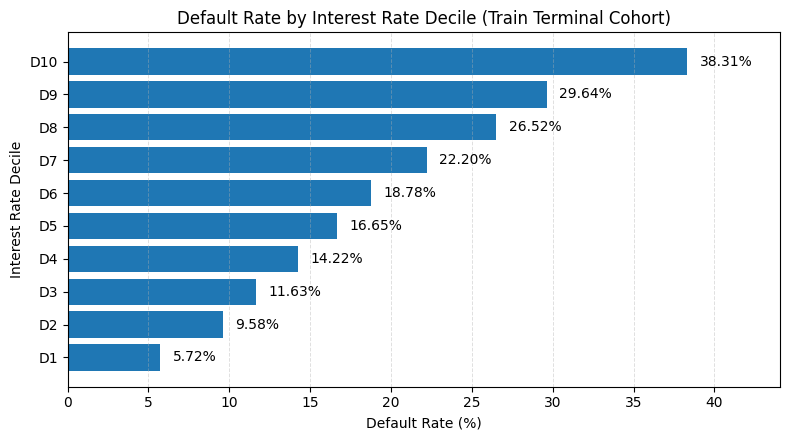

In [21]:
# -------------------------------
# Default rate by interest-rate decile (hierarchy-first plot)
# -------------------------------

plot_dataframe = default_rate_by_int_rate_decile_train.copy()
plot_dataframe = plot_dataframe.reset_index(drop=False)
plot_dataframe["decile"] = [f"D{i+1}" for i in range(len(plot_dataframe))]

values = plot_dataframe["default_rate_percent"].tolist()
labels = plot_dataframe["decile"].tolist()

plt.figure(figsize=(8, 4.5))
bars = plt.barh(labels, values)

plt.xlabel("Default Rate (%)")
plt.ylabel("Interest Rate Decile")
plt.title("Default Rate by Interest Rate Decile (Train Terminal Cohort)")

plt.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
plt.xlim(0, max(values) * 1.15)

# Value labels at bar ends (instant readability)
for bar, value in zip(bars, values):
    plt.text(
        value + (max(values) * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

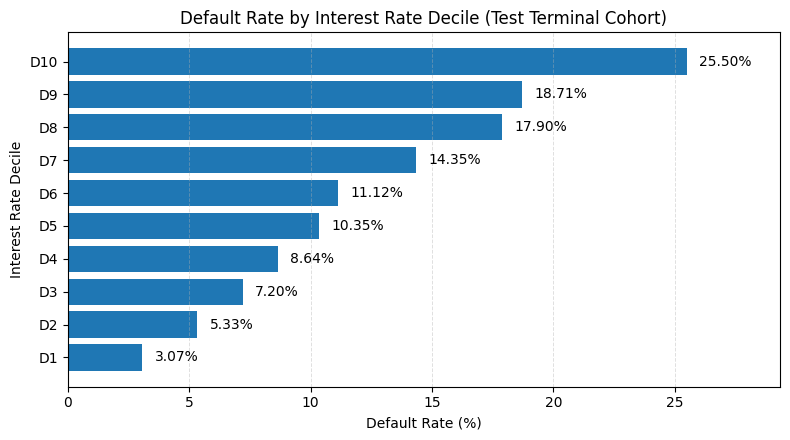

In [22]:
# -------------------------------
# Default rate by interest-rate decile (hierarchy-first plot)
# -------------------------------

plot_dataframe = default_rate_by_int_rate_decile_test.copy()
plot_dataframe = plot_dataframe.reset_index(drop=False)
plot_dataframe["decile"] = [f"D{i+1}" for i in range(len(plot_dataframe))]

values = plot_dataframe["default_rate_percent"].tolist()
labels = plot_dataframe["decile"].tolist()

plt.figure(figsize=(8, 4.5))
bars = plt.barh(labels, values)

plt.xlabel("Default Rate (%)")
plt.ylabel("Interest Rate Decile")
plt.title("Default Rate by Interest Rate Decile (Test Terminal Cohort)")

plt.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
plt.xlim(0, max(values) * 1.15)

# Value labels at bar ends (instant readability)
for bar, value in zip(bars, values):
    plt.text(
        value + (max(values) * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [23]:
# -----------------------------------------------------------
# Default rate by verification_status (train / test)
# -----------------------------------------------------------

default_rate_by_verification_train = (
    df_clean_train_terminal
    .groupby("verification_status")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_values("default_rate_percent")
)

display(default_rate_by_verification_train)

default_rate_by_verification_test = (
    df_clean_test_terminal
    .groupby("verification_status")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent")
    .sort_values("default_rate_percent")
)

display(default_rate_by_verification_test)

,default_rate_percent
verification_status,
not_verified,15.19
source_verified,20.24
verified,21.94


,default_rate_percent
verification_status,
not_verified,9.55
source_verified,12.44
verified,13.79


#### Platform signal validation

The platform’s risk and pricing variables behave consistently with actual loan outcomes in both training and test splits.

- Default rates increase steadily from grade A to grade G in both datasets. Higher grades clearly correspond to higher realized default rates.
- Within each grade, sub-grades generally follow the same stepwise pattern, with risk increasing incrementally. Minor irregularities in some higher-risk buckets are attributable to smaller sample sizes.
- When loans are grouped by interest rate deciles, default rates rise consistently across rate buckets in both splits. Higher interest rates are associated with higher realized default rates.
- At first glance, `verification_status` appears counterintuitive: loans marked as "verified" show higher default rates than "not_verified" loans. However, this reflects risk-based verification rather than a protective effect. Higher-risk borrowers are more likely to be verified by the platform, so verification is applied more frequently to already riskier loans. The elevated default rate therefore reflects borrower risk, not the impact of verification itself.

Overall, the platform’s grading and pricing structure align with realized outcomes across both splits. No structural inconsistencies were identified.
These variables remain excluded from the modeling feature set, but they serve as important benchmark anchors when evaluating model performance later.

In [24]:
# -------------------------------
# Overall missingness (train / test clean)
# -------------------------------

reporting_columns = [
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
]

#  Overall missingness for clean training dataset
missingness_overall_train = (
    df_clean_train_with_year[reporting_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="missing_percent")
)

display(missingness_overall_train)

# Overall missingness for clean test dataset
missingness_overall_test = (
    df_clean_test_with_year[reporting_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="missing_percent")
)

display(missingness_overall_test)

,missing_percent
tot_coll_amt,15.07
tot_cur_bal,15.07
total_rev_hi_lim,15.07


,missing_percent
tot_coll_amt,0.0
tot_cur_bal,0.0
total_rev_hi_lim,0.0


In [25]:
# -------------------------------
# Missingness by issue_year (train clean)
# -------------------------------

# Missingness by issue_year (train clean)
missingness_by_year_train = (
    df_clean_train_with_year
    .groupby("issue_year")[reporting_columns]
    .apply(lambda dataframe: dataframe.isna().mean() * 100)
    .round(2)
)

display(missingness_by_year_train)

# Missingness by issue_year (test clean)
missingness_by_year_test = (
    df_clean_test_with_year
    .groupby("issue_year")[reporting_columns]
    .apply(lambda dataframe: dataframe.isna().mean() * 100)
    .round(2)
)

display(missingness_by_year_test)

,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
issue_year,,,
2007,100.00,100.00,100.00
2008,100.00,100.00,100.00
2009,100.00,100.00,100.00
2010,100.00,100.00,100.00
2011,100.00,100.00,100.00
2012,51.98,51.98,51.98
2013,0.00,0.00,0.00
2014,0.00,0.00,0.00


,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
issue_year,,,
2015,0.0,0.0,0.0


#### Reporting stability assessment

Three credit balance variables (`tot_coll_amt`, `tot_cur_bal`, `total_rev_hi_lim`) exhibit identical missingness patterns across splits.

Training split:
- Loans issued between 2007–2011 show complete absence of these fields.
- 2012 represents a transition year with partial reporting.
- From 2013 onward, reporting is complete.
- Overall missingness (~15%) reflects the share of early vintages rather than borrower-level behavior.

Test split:
- 2015 shows full reporting with 0% missingness across all three variables.

The synchronized pattern across all three variables indicates a reporting regime change rather than random missingness or data corruption.
Observed differences in default rates between missing and non-missing groups in the training split align with vintage structure, not intrinsic borrower characteristics.
These variables remain structurally valid submission-time features but require awareness of their time-dependent availability in subsequent modeling and validation design.

In [26]:
# -------------------------------
# Missingness indicator (train terminal cohort)
# -------------------------------

df_clean_train_terminal = df_clean_train_terminal.copy()

df_clean_train_terminal["tot_cur_bal_missing"] = (
    df_clean_train_terminal["tot_cur_bal"].isna().astype(int)
)

df_clean_train_terminal["tot_coll_amt_missing"] = (
    df_clean_train_terminal["tot_coll_amt"].isna().astype(int)
)

df_clean_train_terminal["total_rev_hi_lim_missing"] = (
    df_clean_train_terminal["total_rev_hi_lim"].isna().astype(int)
)

In [27]:
# -------------------------------
# Default rate by missingness train terminal cohort
# -------------------------------

for column in [
    "tot_cur_bal_missing",
    "tot_coll_amt_missing",
    "total_rev_hi_lim_missing",
]:
    result = (
        df_clean_train_terminal
        .groupby(column)["target_default"]
        .mean()
        .mul(100)
        .round(2)
        .to_frame(name="default_rate_percent")
    )
    
    print(f"\nDefault rate by {column}:")
    display(result)


Default rate by tot_cur_bal_missing:


,default_rate_percent
tot_cur_bal_missing,
0,20.25
1,16.24



Default rate by tot_coll_amt_missing:


,default_rate_percent
tot_coll_amt_missing,
0,20.25
1,16.24



Default rate by total_rev_hi_lim_missing:


,default_rate_percent
total_rev_hi_lim_missing,
0,20.25
1,16.24


In [28]:
# -------------------------------
# Missingness indicator (test terminal cohort)
# -------------------------------

df_clean_test_terminal = df_clean_test_terminal.copy()

df_clean_test_terminal["tot_cur_bal_missing"] = (
    df_clean_test_terminal["tot_cur_bal"].isna().astype(int)
)

df_clean_test_terminal["tot_coll_amt_missing"] = (
    df_clean_test_terminal["tot_coll_amt"].isna().astype(int)
)

df_clean_test_terminal["total_rev_hi_lim_missing"] = (
    df_clean_test_terminal["total_rev_hi_lim"].isna().astype(int)
)

In [29]:
# -------------------------------
# Default rate by missingness test terminal cohort
# -------------------------------

for column in [
    "tot_cur_bal_missing",
    "tot_coll_amt_missing",
    "total_rev_hi_lim_missing",
]:
    result = (
        df_clean_test_terminal
        .groupby(column)["target_default"]
        .mean()
        .mul(100)
        .round(2)
        .to_frame(name="default_rate_percent")
    )
    
    print(f"\nDefault rate by {column}:")
    display(result)


Default rate by tot_cur_bal_missing:


,default_rate_percent
tot_cur_bal_missing,
0,12.09



Default rate by tot_coll_amt_missing:


,default_rate_percent
tot_coll_amt_missing,
0,12.09



Default rate by total_rev_hi_lim_missing:


,default_rate_percent
total_rev_hi_lim_missing,
0,12.09


#### Missingness–outcome relationship

Missingness in `tot_coll_amt`, `tot_cur_bal`, and `total_rev_hi_lim` is associated with lower default rates in the training split (~16%) compared to observations where values are present (~20%).

In the test split, no missingness is observed for these variables (0% missing in 2015), and the realized default rate for the terminal cohort is ~12%.

The lower default rate among missing observations in the training split reflects vintage composition rather than borrower-level behavior. Loans with missing values originate primarily from earlier issuance years, which exhibit different default dynamics than later, fully reported vintages. Therefore, missingness in these variables encodes temporal structure rather than inherent borrower risk. These variables remain valid submission-time features but require careful handling in modeling to avoid implicitly capturing time-based regime effects.

#### 1.6 Diagnostic summary

This diagnostic validation confirms that the `clean` dataset is structurally coherent and suitable to move into decision-focused analysis and later modeling, provided the submission-time boundary is respected and time-related reporting effects are handled explicitly.

---

### Outcome labels and cohort definition

- The `loan_status` labels are consistent and economically interpretable after normalization in both training and test splits.
- A large share of loans appear as `current` in the full datasets. This is explained by vintage concentration in later issuance years (2013–2014 in train, 2015 in test), not by label instability.
- To avoid censoring and ensure outcome certainty, the modeling cohort is restricted to **realized terminal outcomes**:
  - `fully_paid`
  - `charged_off`
  - `default`
  - Policy-flagged terminal variants are collapsed into their corresponding classes:
    - `does_not_meet_the_credit_policy._status:charged_off` → `charged_off`
    - `does_not_meet_the_credit_policy._status:fully_paid` → `fully_paid`

Within the realized terminal cohort:
- Train set default rate ≈ **19%** across ~**230k** observations.
- Test set default rate ≈ **12%** across ~**26k** observations.

The difference in default rates reflects temporal and macroeconomic variation rather than structural inconsistencies.

---

### Temporal structure and maturity effects

- Outcome realization varies strongly by issuance year:
  - Early train vintages (2007–2012) are largely mature and dominated by terminal outcomes.
  - Later train vintages (2013–2014) contain more ongoing loans in the full dataset.
- The 2015 test split represents a more recent vintage and is similarly dominated by ongoing loans in the unrestricted dataset.

Aggregate class balance must therefore be interpreted in a temporal context. Realized-outcome restriction is required for fair comparison and modeling stability.

---

### Economic coherence of outcomes (cashflow validation)

- Post-origination cashflow variables behave consistently with observed loan outcomes in both splits:
  - `fully_paid` loans show near-complete principal repayment and zero outstanding balance.
  - `charged_off` loans show partial repayment and recovery-related values, with balances closed.
  - `default` loans retain substantial outstanding principal, consistent with an active default state.

No contradictions between outcome labels and realized payment behavior were identified. The dataset is internally coherent.

---

### Platform risk and pricing signals (validation benchmarks)

- Origination-time platform signals align with realized default behavior in both splits:
  - Default rates increase steadily from grade A to grade G.
  - Sub-grades generally show stepwise increases in risk.
  - Default rates rise clearly across interest-rate deciles.
- `verification_status` shows higher default rates for verified loans. This reflects risk-based verification practices rather than a protective effect.

These variables are excluded from the modeling feature set but serve as validation benchmarks for later model comparison.

---

### Reporting stability and missingness

- Three credit balance variables (`tot_coll_amt`, `tot_cur_bal`, `total_rev_hi_lim`) show a clear reporting regime shift in the training split:
  - 2007–2011: fully missing
  - 2012: partially reported
  - 2013–2014: fully reported
- The test split (2015) shows full reporting with 0% missingness.
- In the training split, missing observations are associated with lower default rates (~16%) compared to non-missing rows (~20%). This reflects vintage structure rather than borrower-level risk.

These variables remain valid submission-time features, but their time-dependent availability must be handled carefully during modeling to avoid implicit temporal bias.

---

### What this means going forward

- Part 2 (Decision EDA) will focus exclusively on submission-time features in the `feature_base` dataset.
- Modeling will use the realized terminal cohort definition established here.
- Censoring has been addressed via cohort restriction.
- Reporting regime effects must be handled explicitly for balance-related variables.
- Benchmark variables (cashflows and platform signals) remain excluded from training and will serve as validation anchors.

The dataset is structurally sound, economically coherent, and ready for submission-time feature analysis.

## Part 2 — Decision-Focused Analysis (`feature_base`)

This section evaluates submission-time features within the realized terminal cohort defined in Part 1.

The objective is to assess signal strength, economic interpretability, and temporal stability of variables available at loan application submission.

---

#### 2.1 Cohort alignment and baseline risk
- Confirm that the realized terminal cohort is consistently applied to `feature_base`.
- Validate baseline default rate in train and test splits.
- Confirm absence of post-submission leakage.

---

#### 2.2 Feature distribution and scale behavior
- Examine distributions of key numerical features.
- Identify skewness, extreme values, and scale differences.
- Assess whether transformations may be required.

---

#### 2.3 Feature–outcome relationship (univariate signal strength)
- Compute default rate by feature bins (quantiles or meaningful categories).
- Evaluate monotonicity and economic plausibility.
- Identify non-linear or threshold effects.

---

#### 2.4 Informative missingness assessment
- Quantify missingness for submission-time features.
- Evaluate whether missingness encodes risk or structural time effects.
- Distinguish behavioral signal from regime-driven artifacts.

---

#### 2.5 Temporal stability of core predictors
- Compare feature distributions across train (2007–2014) and test (2015).
- Assess stability of feature–default relationships across time.
- Identify variables vulnerable to regime shifts.

---

#### 2.6 Modeling preparation summary
- Confirm final modeling cohort.
- Flag variables requiring transformation or stabilization.
- Identify variables with potential temporal bias.
- Formalize candidate feature set for modeling.


In [30]:
# -------------------------------
# Load feature_base datasets
# -------------------------------

log("Loading feature_base training dataset")
df_feature_base_train = pd.read_parquet(feature_base_training_data_file)
log("feature_base training dataset loaded")

log("Loading feature_base test dataset")
df_feature_base_test = pd.read_parquet(feature_base_test_data_file)
log("feature_base test dataset loaded")

print("df_feature_base_train shape:", df_feature_base_train.shape)
print("df_feature_base_test shape:", df_feature_base_test.shape)

df_feature_base_train shape: (466285, 27)
df_feature_base_test shape: (421094, 27)


In [31]:
# -------------------------------
# Restrict feature_base to realized terminal cohort
# -------------------------------

df_feature_base_train_terminal = build_terminal_cohort(
    df_feature_base_train,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log_file=str(project_log_file),
)

df_feature_base_test_terminal = build_terminal_cohort(
    df_feature_base_test,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log_file=str(project_log_file),
)

print("Feature base train terminal shape:", df_feature_base_train_terminal.shape)
print("Feature base test terminal shape:", df_feature_base_test_terminal.shape)

Feature base train terminal shape: (230795, 28)
Feature base test terminal shape: (26144, 28)


In [32]:
# -------------------------------
# Baseline default rate (feature_base)
# -------------------------------

default_rate_feature_train = round(
    float(df_feature_base_train_terminal["target_default"].mean() * 100),
    2
)

default_rate_feature_test = round(
    float(df_feature_base_test_terminal["target_default"].mean() * 100),
    2
)

print("Feature base train default rate (%):", default_rate_feature_train)
print("Feature base test default rate (%):", default_rate_feature_test)

Feature base train default rate (%): 19.09
Feature base test default rate (%): 12.09


In [33]:
sorted(df_feature_base_train_terminal.columns)

['acc_now_delinq',
 'annual_inc',
 'collections_12_mths_ex_med',
 'delinq_2yrs',
 'dti',
 'emp_length_years',
 'has_mths_since_last_delinq',
 'has_mths_since_last_major_derog',
 'has_mths_since_last_record',
 'home_ownership',
 'inq_last_6mths',
 'loan_amnt',
 'loan_status',
 'mths_since_last_delinq',
 'mths_since_last_major_derog',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'purpose',
 'revol_bal',
 'revol_util',
 'row_id',
 'target_default',
 'term_months',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_acc',
 'total_rev_hi_lim']

In [34]:
# -------------------------------
# Feature: loan_amnt (distribution overview)
# -------------------------------

feature_name = "loan_amnt"

loan_amount_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame(name="train")
)

loan_amount_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame(name="test")
)

loan_amount_summary = loan_amount_summary_train.join(
    loan_amount_summary_test,
    how="outer"
)

loan_amount_summary

,train,test
1%,1500.000000,1500.000000
5%,3000.000000,3000.000000
50%,12000.000000,12000.000000
95%,30000.000000,35000.000000
99%,35000.000000,35000.000000
count,230795.000000,26144.000000
max,35000.000000,35000.000000
mean,13412.187114,14492.549916
min,500.000000,1000.000000
std,8042.975786,8791.252866


In [35]:
# -------------------------------
# Feature: loan_amnt (default rate by decile)
# -------------------------------

feature_name = "loan_amnt"
number_of_bins = 10

df_train = df_feature_base_train_terminal[[feature_name, "target_default"]].copy()
df_test = df_feature_base_test_terminal[[feature_name, "target_default"]].copy()

# Derive bin edges from train only
train_bin_edges = pd.qcut(
    df_train[feature_name],
    q=number_of_bins,
    retbins=True,
    duplicates="drop"
)[1]

df_train["loan_amnt_bin"] = pd.cut(
    df_train[feature_name],
    bins=train_bin_edges,
    include_lowest=True
)

df_test["loan_amnt_bin"] = pd.cut(
    df_test[feature_name],
    bins=train_bin_edges,
    include_lowest=True
)

default_rate_by_loan_amount_bin_train = (
    df_train
    .groupby("loan_amnt_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_loan_amount_bin_test = (
    df_test
    .groupby("loan_amnt_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_loan_amount_bin = (
    default_rate_by_loan_amount_bin_train
    .join(default_rate_by_loan_amount_bin_test, how="outer")
)

default_rate_by_loan_amount_bin

,default_rate_percent_train,default_rate_percent_test
loan_amnt_bin,,
"(499.999, 4500.0]",16.36,9.72
"(4500.0, 6000.0]",16.11,9.98
"(6000.0, 8000.0]",16.65,10.60
"(8000.0, 10000.0]",17.97,11.07
"(10000.0, 12000.0]",18.17,14.53
"(12000.0, 14000.0]",18.51,13.66
"(14000.0, 16000.0]",19.57,12.48
"(16000.0, 20000.0]",21.61,13.49
"(20000.0, 25000.0]",22.16,13.23


In [36]:
# -------------------------------
# Feature: loan_amnt (train vs test stability gap)
# -------------------------------

loan_amount_stability = default_rate_by_loan_amount_bin.reset_index().copy()

loan_amount_stability["gap_test_minus_train"] = (
    loan_amount_stability["default_rate_percent_test"]
    - loan_amount_stability["default_rate_percent_train"]
).round(2)

loan_amount_stability

,loan_amnt_bin,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,"(499.999, 4500.0]",16.36,9.72,-6.64
1,"(4500.0, 6000.0]",16.11,9.98,-6.13
2,"(6000.0, 8000.0]",16.65,10.60,-6.05
3,"(8000.0, 10000.0]",17.97,11.07,-6.90
4,"(10000.0, 12000.0]",18.17,14.53,-3.64
5,"(12000.0, 14000.0]",18.51,13.66,-4.85
6,"(14000.0, 16000.0]",19.57,12.48,-7.09
7,"(16000.0, 20000.0]",21.61,13.49,-8.12
8,"(20000.0, 25000.0]",22.16,13.23,-8.93
9,"(25000.0, 35000.0]",24.74,12.39,-12.35


#### Loan amount signal assessment

Loan amount shows a clear and understandable relationship with default risk.

In the training data:
- Smaller loans (lowest decile) default at around **16%**.
- Larger loans (highest decile) default at around **25%**.
- The increase in default rate is steady as loan size increases.
  
This means that, historically, borrowers requesting larger loans were more likely to default. The pattern is smooth and consistent, which strengthens confidence that the relationship is real and not random noise.

In the test data:
- Overall default rates are lower (around **12%** on average).
- However, the same general pattern holds: larger loans still carry higher default risk.
- The difference between training and test is mostly a shift in overall risk level, not a breakdown of the relationship.

This suggests that the effect of loan size on default risk is stable over time. The magnitude of default changes across years, but the direction of the relationship remains intact.
Distribution checks also show that loan sizes are slightly larger on average in the test period, but not in a way that distorts the relationship.
Overall, `loan_amnt` provides a clear and stable risk signal. Larger requested amounts are consistently associated with higher default rates, making this a strong and interpretable modeling feature.

In [37]:
# -------------------------------
# Feature: annual_inc (distribution overview)
# -------------------------------

feature_name = "annual_inc"

annual_inc_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame(name="train")
)

annual_inc_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame(name="test")
)

annual_inc_summary = annual_inc_summary_train.join(
    annual_inc_summary_test,
    how="outer"
)

annual_inc_summary

,train,test
1%,1.800000e+04,2.000000e+04
5%,2.716150e+04,3.000000e+04
50%,6.192000e+04,6.500000e+04
95%,1.450000e+05,1.550000e+05
99%,2.350000e+05,2.522850e+05
count,2.307910e+05,2.614400e+04
max,7.141778e+06,8.706582e+06
mean,7.200431e+04,7.686452e+04
min,1.896000e+03,6.635000e+03
std,5.542584e+04,8.339655e+04


In [38]:
# -------------------------------
# Feature: annual_inc (default rate by decile)
# -------------------------------

feature_name = "annual_inc"
number_of_bins = 10

df_train = df_feature_base_train_terminal[[feature_name, "target_default"]].copy()
df_test = df_feature_base_test_terminal[[feature_name, "target_default"]].copy()

train_bin_edges = pd.qcut(
    df_train[feature_name],
    q=number_of_bins,
    retbins=True,
    duplicates="drop"
)[1]

df_train["annual_inc_bin"] = pd.cut(
    df_train[feature_name],
    bins=train_bin_edges,
    include_lowest=True
)

df_test["annual_inc_bin"] = pd.cut(
    df_test[feature_name],
    bins=train_bin_edges,
    include_lowest=True
)

default_rate_by_annual_inc_bin_train = (
    df_train
    .groupby("annual_inc_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_annual_inc_bin_test = (
    df_test
    .groupby("annual_inc_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_annual_inc_bin = (
    default_rate_by_annual_inc_bin_train
    .join(default_rate_by_annual_inc_bin_test, how="outer")
)

default_rate_by_annual_inc_bin

,default_rate_percent_train,default_rate_percent_test
annual_inc_bin,,
"(1895.999, 33000.0]",24.93,19.29
"(33000.0, 40500.0]",23.51,15.80
"(40500.0, 48000.0]",21.74,13.74
"(48000.0, 55000.0]",20.64,11.82
"(55000.0, 61920.0]",20.43,12.02
"(61920.0, 70000.0]",18.60,11.11
"(70000.0, 80000.0]",17.25,11.71
"(80000.0, 95000.0]",15.65,10.08
"(95000.0, 120000.0]",14.36,9.08


In [39]:
# -------------------------------
# Feature: annual_inc (train vs test stability)
# -------------------------------

annual_inc_stability = default_rate_by_annual_inc_bin.reset_index().copy()

annual_inc_stability["gap_test_minus_train"] = (
    annual_inc_stability["default_rate_percent_test"]
    - annual_inc_stability["default_rate_percent_train"]
).round(2)

annual_inc_stability

,annual_inc_bin,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,"(1895.999, 33000.0]",24.93,19.29,-5.64
1,"(33000.0, 40500.0]",23.51,15.80,-7.71
2,"(40500.0, 48000.0]",21.74,13.74,-8.00
3,"(48000.0, 55000.0]",20.64,11.82,-8.82
4,"(55000.0, 61920.0]",20.43,12.02,-8.41
5,"(61920.0, 70000.0]",18.60,11.11,-7.49
6,"(70000.0, 80000.0]",17.25,11.71,-5.54
7,"(80000.0, 95000.0]",15.65,10.08,-5.57
8,"(95000.0, 120000.0]",14.36,9.08,-5.28
9,"(120000.0, 7141778.0]",13.25,8.62,-4.63


#### Annual income signal assessment

Annual income shows a clear and consistent relationship with default risk.

In the training data:
- Borrowers in the lowest income group default at approximately **25%**.
- Borrowers in the highest income group default at approximately **13%**.
- Default risk steadily decreases as income increases.

This pattern is economically intuitive: higher-income borrowers generally have greater repayment capacity.

In the test data:
- Overall default levels are lower.
- However, the same downward pattern remains. Higher income consistently corresponds to lower default risk.
- The difference between training and test appears as a general shift in overall risk level, not a breakdown of the relationship.

Income distributions are slightly higher in the test split, and the upper tail contains extreme outliers. These high-income outliers will require consideration during modeling but do not distort the overall risk pattern.

Overall, `annual_inc` provides a strong, stable, and economically interpretable risk signal suitable for modeling.

In [40]:
# -------------------------------
# Feature: dti (distribution overview)
# -------------------------------

feature_name = "dti"

dti_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame(name="train")
)

dti_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame(name="test")
)

dti_summary = dti_summary_train.join(
    dti_summary_test,
    how="outer"
)

dti_summary

,train,test
1%,1.180000,1.564300
5%,4.160000,4.780000
50%,16.050000,17.610000
95%,29.580000,33.440000
99%,33.810000,38.180000
count,230795.000000,26144.000000
max,39.990000,57.140000
mean,16.348890,18.177812
min,0.000000,0.000000
std,7.672534,8.617355


In [41]:
# -------------------------------
# Feature: dti (default rate by decile)
# -------------------------------

feature_name = "dti"
number_of_bins = 10

df_train = df_feature_base_train_terminal[[feature_name, "target_default"]].copy()
df_test = df_feature_base_test_terminal[[feature_name, "target_default"]].copy()

train_bin_edges = pd.qcut(
    df_train[feature_name],
    q=number_of_bins,
    retbins=True,
    duplicates="drop"
)[1]

df_train["dti_bin"] = pd.cut(
    df_train[feature_name],
    bins=train_bin_edges,
    include_lowest=True
)

df_test["dti_bin"] = pd.cut(
    df_test[feature_name],
    bins=train_bin_edges,
    include_lowest=True
)

default_rate_by_dti_bin_train = (
    df_train
    .groupby("dti_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_dti_bin_test = (
    df_test
    .groupby("dti_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_dti_bin = (
    default_rate_by_dti_bin_train
    .join(default_rate_by_dti_bin_test, how="outer")
)

default_rate_by_dti_bin

,default_rate_percent_train,default_rate_percent_test
dti_bin,,
"(-0.001, 6.324]",13.33,7.92
"(6.324, 9.38]",14.07,7.40
"(9.38, 11.79]",15.70,8.25
"(11.79, 13.94]",16.48,9.20
"(13.94, 16.05]",17.30,9.18
"(16.05, 18.21]",18.84,11.29
"(18.21, 20.51]",20.40,10.75
"(20.51, 23.14]",22.00,13.01
"(23.14, 26.78]",24.09,15.07


In [42]:
# -------------------------------
# Feature: dti (train vs test stability)
# -------------------------------

dti_stability = default_rate_by_dti_bin.reset_index().copy()

dti_stability["gap_test_minus_train"] = (
    dti_stability["default_rate_percent_test"]
    - dti_stability["default_rate_percent_train"]
).round(2)

dti_stability

,dti_bin,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,"(-0.001, 6.324]",13.33,7.92,-5.41
1,"(6.324, 9.38]",14.07,7.40,-6.67
2,"(9.38, 11.79]",15.70,8.25,-7.45
3,"(11.79, 13.94]",16.48,9.20,-7.28
4,"(13.94, 16.05]",17.30,9.18,-8.12
5,"(16.05, 18.21]",18.84,11.29,-7.55
6,"(18.21, 20.51]",20.40,10.75,-9.65
7,"(20.51, 23.14]",22.00,13.01,-8.99
8,"(23.14, 26.78]",24.09,15.07,-9.02
9,"(26.78, 39.99]",28.74,19.98,-8.76


#### Debt-to-income (DTI) signal assessment

Debt-to-income ratio shows a strong and consistent relationship with default risk.

In the training data:
- Borrowers in the lowest DTI group default at approximately **13%**.
- Borrowers in the highest DTI group default at approximately **29%**.
- Default risk increases steadily as DTI increases.

This relationship is economically intuitive: borrowers with higher leverage relative to income are more likely to experience repayment difficulty.

In the test data:
- Overall default levels are lower.
- However, the same upward pattern remains. Higher DTI consistently corresponds to higher default risk.
- The difference between training and test appears as a shift in overall risk level rather than a breakdown in the DTI–risk relationship.

DTI levels are slightly higher on average in the test split, but the signal remains stable and monotonic.

Overall, `dti` provides a strong, stable, and economically interpretable risk signal and is likely to be an important modeling feature.

In [43]:
# -------------------------------
# Feature: revol_util (distribution overview)
# -------------------------------

feature_name = "revol_util"

revol_util_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame(name="train")
)

revol_util_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame(name="test")
)

revol_util_summary = revol_util_summary_train.join(
    revol_util_summary_test,
    how="outer"
)

revol_util_summary

,train,test
1%,0.500000,0.600000
5%,10.500000,8.600000
50%,56.500000,49.500000
95%,92.400000,91.600000
99%,97.700000,98.900000
count,230569.000000,26130.000000
max,892.300000,127.600000
mean,54.829677,49.780253
min,0.000000,0.000000
std,24.736154,25.169548


In [44]:
# -------------------------------
# Feature: revol_util (default rate by decile)
# -------------------------------

feature_name = "revol_util"
number_of_bins = 10

df_train = df_feature_base_train_terminal[[feature_name, "target_default"]].copy()
df_test = df_feature_base_test_terminal[[feature_name, "target_default"]].copy()

train_bin_edges = pd.qcut(
    df_train[feature_name],
    q=number_of_bins,
    retbins=True,
    duplicates="drop"
)[1]

df_train["revol_util_bin"] = pd.cut(
    df_train[feature_name],
    bins=train_bin_edges,
    include_lowest=True
)

df_test["revol_util_bin"] = pd.cut(
    df_test[feature_name],
    bins=train_bin_edges,
    include_lowest=True
)

default_rate_by_revol_util_bin_train = (
    df_train
    .groupby("revol_util_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_revol_util_bin_test = (
    df_test
    .groupby("revol_util_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_revol_util_bin = (
    default_rate_by_revol_util_bin_train
    .join(default_rate_by_revol_util_bin_test, how="outer")
)

default_rate_by_revol_util_bin

,default_rate_percent_train,default_rate_percent_test
revol_util_bin,,
"(-0.001, 19.8]",11.82,7.96
"(19.8, 32.2]",14.69,8.31
"(32.2, 41.4]",16.72,10.88
"(41.4, 49.2]",18.25,10.51
"(49.2, 56.5]",19.09,12.18
"(56.5, 63.5]",20.07,12.80
"(63.5, 70.6]",21.24,14.65
"(70.6, 78.2]",21.79,14.47
"(78.2, 87.0]",22.69,16.15


In [45]:
# -------------------------------
# Feature: revol_util (train vs test stability)
# -------------------------------

revol_util_stability = default_rate_by_revol_util_bin.reset_index().copy()

revol_util_stability["gap_test_minus_train"] = (
    revol_util_stability["default_rate_percent_test"]
    - revol_util_stability["default_rate_percent_train"]
).round(2)

revol_util_stability

,revol_util_bin,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,"(-0.001, 19.8]",11.82,7.96,-3.86
1,"(19.8, 32.2]",14.69,8.31,-6.38
2,"(32.2, 41.4]",16.72,10.88,-5.84
3,"(41.4, 49.2]",18.25,10.51,-7.74
4,"(49.2, 56.5]",19.09,12.18,-6.91
5,"(56.5, 63.5]",20.07,12.80,-7.27
6,"(63.5, 70.6]",21.24,14.65,-6.59
7,"(70.6, 78.2]",21.79,14.47,-7.32
8,"(78.2, 87.0]",22.69,16.15,-6.54
9,"(87.0, 892.3]",24.62,19.64,-4.98


#### Revolving utilization signal assessment

Revolving utilization (`revol_util`) shows a strong and consistent relationship with default risk.

In the training data:
- Borrowers with very low utilization default at approximately **12%**.
- Borrowers in the highest utilization group default at approximately **25%**.
- Default risk increases steadily as utilization rises.

In the test data:
- Overall default levels are lower.
- However, the same upward pattern remains. Higher utilization is consistently associated with higher default risk.
- The relationship is stable across time, with no reversal or structural breakdown.

Distribution checks reveal extreme outliers in the upper tail (values above 100%), particularly in the training split. These likely reflect reporting or balance anomalies and will require attention during modeling.
Overall, `revol_util` provides a strong, stable behavioral stress signal and is likely to be a key predictor in the modeling phase.

In [46]:
# -------------------------------
# Feature: inq_last_6mths (distribution overview)
# -------------------------------

feature_name = "inq_last_6mths"

inq_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

inq_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

inq_summary = inq_summary_train.join(
    inq_summary_test,
    how="outer"
)

inq_summary

,train,test
50%,1.000000,0.000000
75%,1.000000,1.000000
90%,2.000000,2.000000
95%,3.000000,3.000000
99%,5.000000,4.000000
count,230766.000000,26144.000000
max,33.000000,6.000000
mean,0.907668,0.712630
min,0.000000,0.000000
std,1.175999,0.976212


In [47]:
# -------------------------------
# Feature: inq_last_6mths (default rate by count)
# -------------------------------

feature_name = "inq_last_6mths"

default_rate_by_inq_train = (
    df_feature_base_train_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_inq_test = (
    df_feature_base_test_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_inq = default_rate_by_inq_train.join(
    default_rate_by_inq_test,
    how="outer"
)

default_rate_by_inq

,default_rate_percent_train,default_rate_percent_test
inq_last_6mths,,
0.0,16.97,10.91
1.0,19.71,13.11
2.0,21.53,13.97
3.0,23.72,16.13
4.0,23.92,10.03
5.0,24.94,13.53
6.0,29.49,0.00
7.0,35.23,NaN
8.0,38.98,NaN


In [48]:
# -------------------------------
# Feature: inq_last_6mths (stability comparison)
# -------------------------------

inq_stability = default_rate_by_inq.reset_index().copy()

inq_stability["gap_test_minus_train"] = (
    inq_stability["default_rate_percent_test"]
    - inq_stability["default_rate_percent_train"]
).round(2)

inq_stability

,inq_last_6mths,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0.0,16.97,10.91,-6.06
1,1.0,19.71,13.11,-6.60
2,2.0,21.53,13.97,-7.56
3,3.0,23.72,16.13,-7.59
4,4.0,23.92,10.03,-13.89
5,5.0,24.94,13.53,-11.41
6,6.0,29.49,0.00,-29.49
7,7.0,35.23,NaN,NaN
8,8.0,38.98,NaN,NaN
9,9.0,36.00,NaN,NaN


#### Recent credit inquiry signal assessment

The number of credit inquiries in the past six months (`inq_last_6mths`) shows a clear relationship with default risk.

In the training data:
- Borrowers with 0 inquiries default at ~17%.
- Risk increases steadily up to ~24% for borrowers with 3 inquiries.
- For very high inquiry counts (4+), default rates become unstable due to very small sample sizes.

In the test data:
- The same upward pattern is visible from 0 to 3 inquiries.
- Overall default levels are lower, but the relative ordering remains consistent.
- High inquiry counts are rare and do not provide reliable estimates.

This confirms that recent credit-seeking behavior is a meaningful risk indicator. However, extreme values are sparse and unstable and will likely require grouping or capping during feature engineering.

Overall, `inq_last_6mths` provides a stable behavioral risk signal within its common range (0–3).

In [49]:
# -------------------------------
# Feature: delinq_2yrs (distribution overview)
# -------------------------------

feature_name = "delinq_2yrs"

delinq_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

delinq_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

delinq_summary = delinq_summary_train.join(
    delinq_summary_test,
    how="outer"
)

delinq_summary

,train,test
50%,0.000000,0.000000
75%,0.000000,0.000000
90%,1.000000,1.000000
95%,1.000000,2.000000
99%,3.000000,4.000000
count,230766.000000,26144.000000
max,29.000000,17.000000
mean,0.243303,0.313150
min,0.000000,0.000000
std,0.724509,0.882563


In [50]:
# -------------------------------
# Feature: delinq_2yrs (default rate by count)
# -------------------------------

default_rate_by_delinq_train = (
    df_feature_base_train_terminal
    .groupby("delinq_2yrs")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_delinq_test = (
    df_feature_base_test_terminal
    .groupby("delinq_2yrs")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_delinq = default_rate_by_delinq_train.join(
    default_rate_by_delinq_test,
    how="outer"
)

default_rate_by_delinq

,default_rate_percent_train,default_rate_percent_test
delinq_2yrs,,
0.0,18.80,11.89
1.0,20.00,12.63
2.0,21.45,12.97
3.0,22.98,14.80
4.0,23.10,13.71
5.0,24.17,15.28
6.0,22.71,14.63
7.0,28.57,5.26
8.0,16.18,10.00


In [51]:
# -------------------------------
# Feature: delinq_2yrs (stability comparison)
# -------------------------------

delinq_stability = default_rate_by_delinq.reset_index().copy()

delinq_stability["gap_test_minus_train"] = (
    delinq_stability["default_rate_percent_test"]
    - delinq_stability["default_rate_percent_train"]
).round(2)

delinq_stability

,delinq_2yrs,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0.0,18.80,11.89,-6.91
1,1.0,20.00,12.63,-7.37
2,2.0,21.45,12.97,-8.48
3,3.0,22.98,14.80,-8.18
4,4.0,23.10,13.71,-9.39
5,5.0,24.17,15.28,-8.89
6,6.0,22.71,14.63,-8.08
7,7.0,28.57,5.26,-23.31
8,8.0,16.18,10.00,-6.18
9,9.0,22.50,16.67,-5.83


#### Recent delinquency signal assessment

The number of delinquencies in the past two years (`delinq_2yrs`) shows a clear and intuitive relationship with default risk.

In the training data:
- Borrowers with no recent delinquencies default at ~19%.
- Default risk increases steadily as the number of delinquencies rises.
- Up to about 3–5 delinquencies, the pattern is stable and monotonic.
- Higher counts become statistically unstable due to very small sample sizes.

In the test data:
- Overall default levels are lower.
- However, the same upward relationship remains visible for common values (0–5).
- Extreme values are rare and do not provide reliable estimates.

This confirms that recent delinquency history is a meaningful and stable repayment stress signal. 

However, extreme values are sparse and will likely require grouping or capping during feature engineering to prevent overfitting.

In [52]:
# -------------------------------
# Feature: pub_rec (distribution overview)
# -------------------------------

feature_name = "pub_rec"

pub_rec_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

pub_rec_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

pub_rec_summary = pub_rec_summary_train.join(
    pub_rec_summary_test,
    how="outer"
)

pub_rec_summary

,train,test
50%,0.000000,0.000000
75%,0.000000,0.000000
90%,1.000000,1.000000
95%,1.000000,1.000000
99%,2.000000,2.000000
count,230766.000000,26144.000000
max,11.000000,15.000000
mean,0.132819,0.236345
min,0.000000,0.000000
std,0.417652,0.564767


In [53]:
# -------------------------------
# Feature: pub_rec (default rate by count)
# -------------------------------

default_rate_by_pub_train = (
    df_feature_base_train_terminal
    .groupby("pub_rec")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_pub_test = (
    df_feature_base_test_terminal
    .groupby("pub_rec")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_pub = default_rate_by_pub_train.join(
    default_rate_by_pub_test,
    how="outer"
)

default_rate_by_pub

,default_rate_percent_train,default_rate_percent_test
pub_rec,,
0.0,18.99,12.19
1.0,19.67,11.42
2.0,21.90,11.85
3.0,18.71,13.92
4.0,24.85,12.82
5.0,26.58,33.33
6.0,22.86,25.00
7.0,31.25,0.00
8.0,0.00,0.00


In [54]:
# -------------------------------
# Feature: pub_rec (stability comparison)
# -------------------------------

pub_rec_stability = default_rate_by_pub.reset_index().copy()

pub_rec_stability["gap_test_minus_train"] = (
    pub_rec_stability["default_rate_percent_test"]
    - pub_rec_stability["default_rate_percent_train"]
).round(2)

pub_rec_stability

,pub_rec,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0.0,18.99,12.19,-6.80
1,1.0,19.67,11.42,-8.25
2,2.0,21.90,11.85,-10.05
3,3.0,18.71,13.92,-4.79
4,4.0,24.85,12.82,-12.03
5,5.0,26.58,33.33,6.75
6,6.0,22.86,25.00,2.14
7,7.0,31.25,0.00,-31.25
8,8.0,0.00,0.00,0.00
9,9.0,40.00,NaN,NaN


#### Public record signal assessment

The number of public records (`pub_rec`) shows limited separation in default risk.

In the training data:
- Borrowers with 0 public records default at ~19%.
- Risk increases slightly for 1–2 records.
- Higher counts become unstable due to very small sample sizes.

In the test data:
- Default rates are generally lower.
- The upward pattern is not clearly preserved.
- Values above 2 are rare and statistically unreliable.

Overall, `pub_rec` appears to provide only modest additional risk information. It may still contribute incremental signal, but it is weaker and less stable than recent delinquency or inquiry variables.

If used in modeling, grouping into simple categories (e.g., 0 vs 1+) will likely be more appropriate than keeping raw counts.

In [55]:
# -------------------------------
# Feature: collections_12_mths_ex_med (distribution overview)
# -------------------------------

feature_name = "collections_12_mths_ex_med"

collections_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

collections_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

collections_summary = collections_summary_train.join(
    collections_summary_test,
    how="outer"
)

collections_summary

,train,test
50%,0.000000,0.000000
75%,0.000000,0.000000
90%,0.000000,0.000000
95%,0.000000,0.000000
99%,0.000000,1.000000
count,230650.000000,26144.000000
max,6.000000,3.000000
mean,0.005697,0.015568
min,0.000000,0.000000
std,0.081990,0.134462


In [56]:
# -------------------------------
# Feature: collections_12_mths_ex_med (default rate by count)
# -------------------------------

default_rate_by_collections_train = (
    df_feature_base_train_terminal
    .groupby("collections_12_mths_ex_med")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_collections_test = (
    df_feature_base_test_terminal
    .groupby("collections_12_mths_ex_med")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_collections = default_rate_by_collections_train.join(
    default_rate_by_collections_test,
    how="outer"
)

default_rate_by_collections

,default_rate_percent_train,default_rate_percent_test
collections_12_mths_ex_med,,
0.0,19.07,11.97
1.0,24.26,19.82
2.0,17.19,21.21
3.0,0.00,0.00
4.0,50.00,NaN
5.0,0.00,NaN
6.0,0.00,NaN


In [57]:
# -------------------------------
# Feature: collections_12_mths_ex_med (stability comparison)
# -------------------------------

collections_stability = default_rate_by_collections.reset_index().copy()

collections_stability["gap_test_minus_train"] = (
    collections_stability["default_rate_percent_test"]
    - collections_stability["default_rate_percent_train"]
).round(2)

collections_stability

,collections_12_mths_ex_med,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0.0,19.07,11.97,-7.10
1,1.0,24.26,19.82,-4.44
2,2.0,17.19,21.21,4.02
3,3.0,0.00,0.00,0.00
4,4.0,50.00,NaN,NaN
5,5.0,0.00,NaN,NaN
6,6.0,0.00,NaN,NaN


#### Recent collections signal assessment

The number of non-medical collections in the past 12 months (`collections_12_mths_ex_med`) is extremely rare but informative.

In the training data:
- Borrowers with no recent collections default at ~19%.
- Borrowers with at least one collection default at ~24%.
- Counts above 1 are very rare and statistically unstable.

In the test data:
- The same pattern is visible.
- Default risk increases sharply from 0 to 1 collection.
- Higher counts are too sparse to draw reliable conclusions.

This indicates that even a single recent collection is a meaningful repayment stress signal. However, raw counts beyond 1 provide little additional stable information.

For modeling, this feature will likely be treated as a binary indicator (0 vs 1+).

In [58]:
# -------------------------------
# Default rate by missingness test terminal cohort
# -------------------------------

for column in [
    "tot_cur_bal_missing",
    "tot_coll_amt_missing",
    "total_rev_hi_lim_missing",
]:
    result = (
        df_clean_test_terminal
        .groupby(column)["target_default"]
        .mean()
        .mul(100)
        .round(2)
        .to_frame(name="default_rate_percent")
    )
    
    print(f"\nDefault rate by {column}:")
    display(result)


Default rate by tot_cur_bal_missing:


,default_rate_percent
tot_cur_bal_missing,
0,12.09



Default rate by tot_coll_amt_missing:


,default_rate_percent
tot_coll_amt_missing,
0,12.09



Default rate by total_rev_hi_lim_missing:


,default_rate_percent
total_rev_hi_lim_missing,
0,12.09


In [59]:
# -------------------------------
# Feature: acc_now_delinq (default rate by count)
# -------------------------------

default_rate_by_acc_now_train = (
    df_feature_base_train_terminal
    .groupby("acc_now_delinq")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_acc_now_test = (
    df_feature_base_test_terminal
    .groupby("acc_now_delinq")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_acc_now = default_rate_by_acc_now_train.join(
    default_rate_by_acc_now_test,
    how="outer"
)

default_rate_by_acc_now

,default_rate_percent_train,default_rate_percent_test
acc_now_delinq,,
0.0,19.08,12.07
1.0,23.81,13.97
2.0,23.08,30.00
3.0,66.67,NaN
4.0,0.00,NaN
5.0,50.00,NaN


In [60]:
# -------------------------------
# Feature: acc_now_delinq (stability comparison)
# -------------------------------

acc_now_stability = default_rate_by_acc_now.reset_index().copy()

acc_now_stability["gap_test_minus_train"] = (
    acc_now_stability["default_rate_percent_test"]
    - acc_now_stability["default_rate_percent_train"]
).round(2)

acc_now_stability

,acc_now_delinq,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0.0,19.08,12.07,-7.01
1,1.0,23.81,13.97,-9.84
2,2.0,23.08,30.00,6.92
3,3.0,66.67,NaN,NaN
4,4.0,0.00,NaN,NaN
5,5.0,50.00,NaN,NaN


#### Active delinquency signal assessment

The number of accounts currently delinquent (`acc_now_delinq`) is rare but informative.

In the training data:
- Borrowers with no active delinquencies default at ~19%.
- Borrowers with at least one active delinquency default at ~24%.
- Counts above 1 are extremely rare and statistically unstable.

In the test data:
- Overall default levels are lower.
- The increase from 0 to 1 remains visible, though smaller.
- Higher counts are too sparse to draw reliable conclusions.

This confirms that having an account currently delinquent is a meaningful repayment stress signal. However, raw counts beyond 1 provide little stable information.

For modeling, this feature will likely be treated as a binary indicator (0 vs 1+).

In [61]:
# -------------------------------
# Feature: open_acc (distribution overview)
# -------------------------------

feature_name = "open_acc"

open_acc_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

open_acc_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

open_acc_summary = open_acc_summary_train.join(
    open_acc_summary_test,
    how="outer"
)

open_acc_summary

,train,test
1%,3.000000,3.000000
5%,4.000000,5.000000
50%,10.000000,11.000000
90%,17.000000,19.000000
95%,20.000000,22.000000
99%,25.000000,30.000000
count,230766.000000,26144.000000
max,76.000000,56.000000
mean,10.827878,11.880699
min,0.000000,1.000000


In [62]:
# -------------------------------
# Feature: open_acc (consistent decile bins)
# -------------------------------

feature_name = "open_acc"

# Fit bins on train only
train_bins = pd.qcut(
    df_feature_base_train_terminal[feature_name],
    q=10,
    duplicates="drop",
    retbins=True
)[1]

# Apply bins to train
df_feature_base_train_terminal["open_acc_bin"] = pd.cut(
    df_feature_base_train_terminal[feature_name],
    bins=train_bins,
    include_lowest=True
)

# Apply SAME bins to test
df_feature_base_test_terminal["open_acc_bin"] = pd.cut(
    df_feature_base_test_terminal[feature_name],
    bins=train_bins,
    include_lowest=True
)

default_rate_by_open_acc_train = (
    df_feature_base_train_terminal
    .groupby("open_acc_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_open_acc_test = (
    df_feature_base_test_terminal
    .groupby("open_acc_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_open_acc = default_rate_by_open_acc_train.join(
    default_rate_by_open_acc_test,
    how="outer"
)

default_rate_by_open_acc

,default_rate_percent_train,default_rate_percent_test
open_acc_bin,,
"(-0.001, 5.0]",18.16,13.08
"(5.0, 7.0]",18.17,12.48
"(7.0, 8.0]",18.55,12.40
"(8.0, 9.0]",18.97,11.40
"(9.0, 10.0]",19.36,12.27
"(10.0, 11.0]",19.73,11.72
"(11.0, 13.0]",19.32,12.73
"(13.0, 14.0]",19.61,10.91
"(14.0, 17.0]",19.61,12.55


In [63]:
# -------------------------------
# Feature: open_acc (stability comparison)
# -------------------------------

open_acc_stability = default_rate_by_open_acc.reset_index().copy()

open_acc_stability["gap_test_minus_train"] = (
    open_acc_stability["default_rate_percent_test"]
    - open_acc_stability["default_rate_percent_train"]
).round(2)

open_acc_stability

,open_acc_bin,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,"(-0.001, 5.0]",18.16,13.08,-5.08
1,"(5.0, 7.0]",18.17,12.48,-5.69
2,"(7.0, 8.0]",18.55,12.40,-6.15
3,"(8.0, 9.0]",18.97,11.40,-7.57
4,"(9.0, 10.0]",19.36,12.27,-7.09
5,"(10.0, 11.0]",19.73,11.72,-8.01
6,"(11.0, 13.0]",19.32,12.73,-6.59
7,"(13.0, 14.0]",19.61,10.91,-8.70
8,"(14.0, 17.0]",19.61,12.55,-7.06
9,"(17.0, 76.0]",20.36,10.99,-9.37


#### Credit breadth signal assessment (open accounts)

The number of open credit accounts (`open_acc`) shows only a weak relationship with default risk.

In the training data:
- Default rates increase slightly from ~18% to ~20% across deciles.
- The slope is shallow and nearly flat.

In the test data:
- Default rates range from ~11% to ~13%.
- The overall shape remains flat and stable.

This suggests that the number of open accounts alone is not a strong standalone predictor of default. It may contribute incremental information in combination with other features, but it does not exhibit strong monotonic separation.

Compared to repayment stress variables, `open_acc` appears to be a relatively weak signal.

In [64]:
# -------------------------------
# Feature: total_acc (distribution overview)
# -------------------------------

feature_name = "total_acc"

total_acc_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

total_acc_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

total_acc_summary = total_acc_summary_train.join(
    total_acc_summary_test,
    how="outer"
)

total_acc_summary

,train,test
1%,5.000000,6.000000
5%,9.000000,10.000000
50%,23.000000,25.000000
90%,41.000000,44.000000
95%,47.000000,50.000000
99%,59.000000,64.000000
count,230766.000000,26144.000000
max,150.000000,110.000000
mean,24.790181,26.967297
min,1.000000,4.000000


In [65]:
# -------------------------------
# Feature: total_acc (default rate by decile)
# -------------------------------

feature_name = "total_acc"

# Fit bins on train
train_bins = pd.qcut(
    df_feature_base_train_terminal[feature_name],
    q=10,
    duplicates="drop",
    retbins=True
)[1]

# Apply bins consistently
df_feature_base_train_terminal["total_acc_bin"] = pd.cut(
    df_feature_base_train_terminal[feature_name],
    bins=train_bins,
    include_lowest=True
)

df_feature_base_test_terminal["total_acc_bin"] = pd.cut(
    df_feature_base_test_terminal[feature_name],
    bins=train_bins,
    include_lowest=True
)

default_rate_by_total_acc_train = (
    df_feature_base_train_terminal
    .groupby("total_acc_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_by_total_acc_test = (
    df_feature_base_test_terminal
    .groupby("total_acc_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_by_total_acc = default_rate_by_total_acc_train.join(
    default_rate_by_total_acc_test,
    how="outer"
)

default_rate_by_total_acc

,default_rate_percent_train,default_rate_percent_test
total_acc_bin,,
"(0.999, 11.0]",20.98,16.06
"(11.0, 15.0]",20.30,13.99
"(15.0, 18.0]",19.61,13.82
"(18.0, 20.0]",19.96,12.71
"(20.0, 23.0]",19.21,12.77
"(23.0, 26.0]",18.90,12.24
"(26.0, 30.0]",18.41,10.81
"(30.0, 34.0]",18.09,10.89
"(34.0, 41.0]",17.59,10.15


In [66]:
# -------------------------------
# Feature: total_acc (stability comparison)
# -------------------------------

total_acc_stability = default_rate_by_total_acc.reset_index().copy()

total_acc_stability["gap_test_minus_train"] = (
    total_acc_stability["default_rate_percent_test"]
    - total_acc_stability["default_rate_percent_train"]
).round(2)

total_acc_stability

,total_acc_bin,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,"(0.999, 11.0]",20.98,16.06,-4.92
1,"(11.0, 15.0]",20.30,13.99,-6.31
2,"(15.0, 18.0]",19.61,13.82,-5.79
3,"(18.0, 20.0]",19.96,12.71,-7.25
4,"(20.0, 23.0]",19.21,12.77,-6.44
5,"(23.0, 26.0]",18.90,12.24,-6.66
6,"(26.0, 30.0]",18.41,10.81,-7.60
7,"(30.0, 34.0]",18.09,10.89,-7.20
8,"(34.0, 41.0]",17.59,10.15,-7.44
9,"(41.0, 150.0]",17.54,9.62,-7.92


#### Credit history depth assessment (total accounts)

The total number of credit accounts (`total_acc`) shows a clear and stable relationship with default risk.

In the training data:
- Borrowers with very few total accounts default at ~21%.
- Default risk decreases steadily as total account count increases.
- The highest decile shows default rates near ~17.5%.

In the test data:
- The same downward pattern is preserved.
- Default rates decrease from ~16% to below 10% across bins.
- The relationship remains monotonic and stable across time.

This suggests that deeper credit history is associated with lower default risk. Borrowers with more total accounts likely have longer credit experience and more established repayment behavior.

Compared to `open_acc`, `total_acc` provides a stronger and more consistent signal and is a good candidate for inclusion in the modeling feature set.

In [67]:
# -------------------------------
# Feature: term_months
# -------------------------------

feature_name = "term_months"

# Default rate by term (train)
default_rate_term_train = (
    df_feature_base_train_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

# Default rate by term (test)
default_rate_term_test = (
    df_feature_base_test_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

# Combine
default_rate_term = default_rate_term_train.join(
    default_rate_term_test,
    how="outer"
).reset_index()

default_rate_term["gap_test_minus_train"] = (
    default_rate_term["default_rate_percent_test"]
    - default_rate_term["default_rate_percent_train"]
).round(2)

default_rate_term

,term_months,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,36,15.76,10.11,-5.65
1,60,31.38,16.72,-14.66


#### Loan term (`term_months`)

Default risk increases substantially for longer loan terms.

- In the training period (2007–2014), 60-month loans exhibit roughly double the default rate of 36-month loans.
- The same directional relationship holds in the 2015 test split, although absolute default rates are lower due to period effects.
- The risk ordering remains consistent across time.

Longer loan duration increases cumulative exposure to default and likely reflects both borrower selection and underwriting segmentation.

`term_months` is a strong and stable risk indicator and will remain in the modeling feature set without transformation.

In [68]:
# -------------------------------
# Feature: home_ownership
# -------------------------------

feature_name = "home_ownership"

# Default rate by category (train)
default_rate_home_train = (
    df_feature_base_train_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

# Default rate by category (test)
default_rate_home_test = (
    df_feature_base_test_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

# Combine
default_rate_home = default_rate_home_train.join(
    default_rate_home_test,
    how="outer"
).reset_index()

default_rate_home["gap_test_minus_train"] = (
    default_rate_home["default_rate_percent_test"]
    - default_rate_home["default_rate_percent_train"]
).round(2)

default_rate_home

,home_ownership,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,mortgage,17.16,9.45,-7.71
1,other,20.18,NaN,NaN
2,own,19.93,11.19,-8.74
3,rent,21.18,15.69,-5.49


In [69]:
# Volume check
home_volume = (
    df_feature_base_train_terminal["home_ownership"]
    .value_counts()
    .to_frame(name="train_count")
    .join(
        df_feature_base_test_terminal["home_ownership"]
        .value_counts().to_frame(name="test_count"),
        how="outer"
    )
)

home_volume

,train_count,test_count
home_ownership,,
mortgage,113627,12971
other,228,0
own,19334,2948
rent,97606,10225


#### Home ownership (`home_ownership`)

Default rates vary across home ownership categories in a consistent and economically interpretable way.

- In the training period (2007–2014), mortgage holders show the lowest default rate (~17%), followed by borrowers who own their home outright (~20%), while renters exhibit the highest default rate (~21%).
- The same ordering holds in the 2015 test split, although overall default rates are lower due to period effects.
- The relationship is directionally stable across time.

The fact that mortgage holders perform better than outright owners may reflect selection effects. Borrowers with active mortgages must qualify for mortgage underwriting, which may proxy income stability and stronger credit profiles. The `own` category likely represents a more heterogeneous group.

Volume distribution shows that:
- `mortgage` and `rent` dominate the population.
- `own` is smaller but still meaningful.
- `other` represents a negligible fraction of observations and is absent in the test split.

From a modeling perspective:
- `home_ownership` provides moderate segmentation power.
- The feature will remain in the modeling set.
- The `other` category will be reviewed during feature encoding due to its extremely low volume and lack of representation in the test period.

In [71]:
# -------------------------------
# Feature: emp_length_years
# Distribution overview (train + test)
# -------------------------------

feature_name = "emp_length_years"

emp_length_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

emp_length_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

emp_length_summary = emp_length_summary_train.join(
    emp_length_summary_test,
    how="outer"
)

emp_length_summary

,train,test
1%,0.0,0.0
5%,0.0,0.0
50%,6.0,7.0
90%,10.0,10.0
95%,10.0,10.0
99%,10.0,10.0
count,222040.0,24897.0
max,10.0,10.0
mean,5.783958,6.065349
min,0.0,0.0


In [72]:
# -------------------------------
# Feature: emp_length_years
# Default rate by employment length (train + test)
# -------------------------------

feature_name = "emp_length_years"

default_rate_emp_train = (
    df_feature_base_train_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_emp_test = (
    df_feature_base_test_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_emp = default_rate_emp_train.join(
    default_rate_emp_test,
    how="outer"
).reset_index()

default_rate_emp["gap_test_minus_train"] = (
    default_rate_emp["default_rate_percent_test"]
    - default_rate_emp["default_rate_percent_train"]
).round(2)

default_rate_emp

,emp_length_years,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0.0,19.40,14.29,-5.11
1,1.0,18.51,15.49,-3.02
2,2.0,18.21,11.07,-7.14
3,3.0,18.52,11.87,-6.65
4,4.0,18.00,13.61,-4.39
5,5.0,18.64,13.11,-5.53
6,6.0,19.22,12.56,-6.66
7,7.0,19.54,12.93,-6.61
8,8.0,19.83,10.37,-9.46
9,9.0,19.78,13.03,-6.75


#### Employment length (`emp_length_years`)

Employment tenure exhibits limited separation power.

- Default rates vary only within a narrow range (approximately 18–20% in the training set).
- No clear monotonic relationship is observed between tenure length and default risk.
- The same weak pattern holds in the 2015 test split.

While employment stability is intuitively relevant, its marginal predictive strength appears limited in the presence of stronger financial and credit variables.

`emp_length_years` will remain available for modeling but is considered a weak signal feature and may be pruned if it does not contribute meaningfully during model evaluation.

In [73]:
# -------------------------------
# Feature: purpose
# Volume overview (train + test)
# -------------------------------

feature_name = "purpose"

purpose_volume_train = (
    df_feature_base_train_terminal[feature_name]
    .value_counts()
    .to_frame(name="train_count")
)

purpose_volume_test = (
    df_feature_base_test_terminal[feature_name]
    .value_counts()
    .to_frame(name="test_count")
)

purpose_volume = purpose_volume_train.join(
    purpose_volume_test,
    how="outer"
).fillna(0).astype(int)

purpose_volume

,train_count,test_count
purpose,,
car,3460,260
credit_card,46050,4599
debt_consolidation,133920,16333
educational,422,0
home_improvement,13446,1744
house,1499,204
major_purchase,5852,550
medical,2643,284
moving,1849,236


In [74]:
# -------------------------------
# Feature: purpose
# Default rate by category (train + test)
# -------------------------------

feature_name = "purpose"

default_rate_purpose_train = (
    df_feature_base_train_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_purpose_test = (
    df_feature_base_test_terminal
    .groupby(feature_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_purpose = default_rate_purpose_train.join(
    default_rate_purpose_test,
    how="outer"
).reset_index()

default_rate_purpose["gap_test_minus_train"] = (
    default_rate_purpose["default_rate_percent_test"]
    - default_rate_purpose["default_rate_percent_train"]
).round(2)

default_rate_purpose

,purpose,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,car,12.80,10.77,-2.03
1,credit_card,16.53,11.26,-5.27
2,debt_consolidation,19.92,12.31,-7.61
3,educational,20.85,NaN,NaN
4,home_improvement,16.56,9.17,-7.39
5,house,18.95,9.80,-9.15
6,major_purchase,14.35,12.91,-1.44
7,medical,20.92,18.66,-2.26
8,moving,22.39,15.68,-6.71
9,other,22.08,12.65,-9.43


#### Loan purpose (`purpose`)

Loan purpose exhibits meaningful segmentation in default behavior.

- In the training period, `small_business` loans show the highest default rates (~30%), followed by `moving`, `medical`, and `other`.
- `debt_consolidation`, which represents the largest share of the portfolio, shows elevated risk relative to `credit_card` and `home_improvement`.
- Lower-risk categories include `car`, `major_purchase`, and `wedding`.

The same directional structure holds in the 2015 test split, although absolute default rates are lower due to overall period effects.

Some categories (e.g., `educational`, `renewable_energy`, `wedding`) have very low volume and limited representation in the test period. These may require grouping during feature engineering to ensure stability.

Overall, `purpose` provides meaningful segmentation and will remain in the modeling feature set.

In [76]:
# -------------------------------
# Feature: mths_since_last_delinq
# Distribution overview (train + test)
# -------------------------------

feature_name = "mths_since_last_delinq"

delinq_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

delinq_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

delinq_summary = delinq_summary_train.join(
    delinq_summary_test,
    how="outer"
)

delinq_summary

,train,test
1%,3.000000,2.000000
5%,9.000000,8.000000
50%,9999.000000,81.000000
90%,9999.000000,9999.000000
95%,9999.000000,9999.000000
99%,9999.000000,9999.000000
count,230795.000000,26144.000000
max,9999.000000,9999.000000
mean,5633.790173,4974.901125
min,0.000000,0.000000


In [77]:
# -------------------------------
# Missingness for mths_since_last_delinq
# -------------------------------

delinq_missing = pd.DataFrame(
    {
        "train_missing_percent": [
            round(
                df_feature_base_train_terminal[feature_name].isna().mean() * 100,
                2
            )
        ],
        "test_missing_percent": [
            round(
                df_feature_base_test_terminal[feature_name].isna().mean() * 100,
                2
            )
        ]
    },
    index=[feature_name]
)

delinq_missing

,train_missing_percent,test_missing_percent
mths_since_last_delinq,0.0,0.0


In [78]:
# -------------------------------
# Default rate by has_mths_since_last_delinq
# -------------------------------

flag_name = "has_mths_since_last_delinq"

default_rate_flag_train = (
    df_feature_base_train_terminal
    .groupby(flag_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_flag_test = (
    df_feature_base_test_terminal
    .groupby(flag_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_flag = default_rate_flag_train.join(
    default_rate_flag_test,
    how="outer"
).reset_index()

default_rate_flag["gap_test_minus_train"] = (
    default_rate_flag["default_rate_percent_test"]
    - default_rate_flag["default_rate_percent_train"]
).round(2)

default_rate_flag

,has_mths_since_last_delinq,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0,18.80,12.40,-6.4
1,1,19.48,11.78,-7.7


In [79]:
# -------------------------------
# Default rate by mths_since_last_delinq (train-fitted bins)
# -------------------------------

feature_name = "mths_since_last_delinq"

# Fit bins on train non-null values
train_non_null = df_feature_base_train_terminal[feature_name].dropna()

train_bins = pd.qcut(
    train_non_null,
    q=10,
    duplicates="drop",
    retbins=True
)[1]

df_feature_base_train_terminal["delinq_recency_bin"] = pd.cut(
    df_feature_base_train_terminal[feature_name],
    bins=train_bins,
    include_lowest=True
)

df_feature_base_test_terminal["delinq_recency_bin"] = pd.cut(
    df_feature_base_test_terminal[feature_name],
    bins=train_bins,
    include_lowest=True
)

default_rate_delinq_train = (
    df_feature_base_train_terminal
    .groupby("delinq_recency_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_delinq_test = (
    df_feature_base_test_terminal
    .groupby("delinq_recency_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_delinq = default_rate_delinq_train.join(
    default_rate_delinq_test,
    how="outer"
).reset_index()

default_rate_delinq["gap_test_minus_train"] = (
    default_rate_delinq["default_rate_percent_test"]
    - default_rate_delinq["default_rate_percent_train"]
).round(2)

default_rate_delinq

,delinq_recency_bin,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,"(-0.001, 15.0]",21.52,14.09,-7.43
1,"(15.0, 29.0]",19.29,10.92,-8.37
2,"(29.0, 45.0]",18.47,10.72,-7.75
3,"(45.0, 70.0]",18.77,11.76,-7.01
4,"(70.0, 9999.0]",18.81,12.25,-6.56


#### Delinquency recency (`mths_since_last_delinq`)

This variable uses a sentinel value (9999) to represent borrowers with no prior delinquency history. It therefore combines two structural regimes: borrowers with no delinquency record and borrowers with varying recency of past delinquency.

- Borrowers with very recent delinquency (0–15 months) exhibit elevated default rates (~21.5% in train).
- As delinquency becomes more distant in time, default rates decline and stabilize around ~18–19%.
- The difference between borrowers with no delinquency history and those with older delinquency events is modest.

The signal is economically intuitive but moderate in magnitude. Recency appears more important than mere presence of a historical delinquency.

During feature engineering, the sentinel value (9999) will require explicit treatment to avoid misinterpretation as a large numeric value.

In [80]:
# -------------------------------
# Feature: mths_since_last_major_derog
# Distribution overview (train + test)
# -------------------------------

feature_name = "mths_since_last_major_derog"

major_derog_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

major_derog_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

major_derog_summary = major_derog_summary_train.join(
    major_derog_summary_test,
    how="outer"
)

major_derog_summary

,train,test
1%,10.000000,8.000000
5%,28.000000,22.000000
50%,9999.000000,9999.000000
90%,9999.000000,9999.000000
95%,9999.000000,9999.000000
99%,9999.000000,9999.000000
count,230795.000000,26144.000000
max,9999.000000,9999.000000
mean,8263.465721,7088.891103
min,0.000000,0.000000


In [81]:
# -------------------------------
# Missingness for mths_since_last_major_derog
# -------------------------------

major_derog_missing = pd.DataFrame(
    {
        "train_missing_percent": [
            round(
                df_feature_base_train_terminal[feature_name].isna().mean() * 100,
                2
            )
        ],
        "test_missing_percent": [
            round(
                df_feature_base_test_terminal[feature_name].isna().mean() * 100,
                2
            )
        ]
    },
    index=[feature_name]
)

major_derog_missing

,train_missing_percent,test_missing_percent
mths_since_last_major_derog,0.0,0.0


In [82]:
# -------------------------------
# Default rate by has_mths_since_last_major_derog
# -------------------------------

flag_name = "has_mths_since_last_major_derog"

default_rate_major_flag_train = (
    df_feature_base_train_terminal
    .groupby(flag_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_major_flag_test = (
    df_feature_base_test_terminal
    .groupby(flag_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_major_flag = default_rate_major_flag_train.join(
    default_rate_major_flag_test,
    how="outer"
).reset_index()

default_rate_major_flag["gap_test_minus_train"] = (
    default_rate_major_flag["default_rate_percent_test"]
    - default_rate_major_flag["default_rate_percent_train"]
).round(2)

default_rate_major_flag

,has_mths_since_last_major_derog,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0,18.84,12.12,-6.72
1,1,20.30,12.01,-8.29


In [83]:
# -------------------------------
# Default rate by mths_since_last_major_derog (train-fitted bins)
# -------------------------------

feature_name = "mths_since_last_major_derog"

train_non_null = df_feature_base_train_terminal[feature_name].dropna()

train_bins = pd.qcut(
    train_non_null,
    q=10,
    duplicates="drop",
    retbins=True
)[1]

df_feature_base_train_terminal["major_derog_recency_bin"] = pd.cut(
    df_feature_base_train_terminal[feature_name],
    bins=train_bins,
    include_lowest=True
)

df_feature_base_test_terminal["major_derog_recency_bin"] = pd.cut(
    df_feature_base_test_terminal[feature_name],
    bins=train_bins,
    include_lowest=True
)

default_rate_major_train = (
    df_feature_base_train_terminal
    .groupby("major_derog_recency_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_major_test = (
    df_feature_base_test_terminal
    .groupby("major_derog_recency_bin")["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_major = default_rate_major_train.join(
    default_rate_major_test,
    how="outer"
).reset_index()

default_rate_major["gap_test_minus_train"] = (
    default_rate_major["default_rate_percent_test"]
    - default_rate_major["default_rate_percent_train"]
).round(2)

default_rate_major

,major_derog_recency_bin,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,"(-0.001, 47.0]",20.44,12.34,-8.1
1,"(47.0, 9999.0]",18.94,12.04,-6.9


#### Major derogatory event recency (`mths_since_last_major_derog`)

This variable uses a sentinel value (9999) to represent borrowers with no prior major derogatory event.

- Borrowers with recent major derogatory events show elevated default rates (~20.4% in train).
- Borrowers with older or no major derogatory history cluster around ~18.9%.
- The effect is directionally stable in the test period, though compressed due to lower overall default rates.

The magnitude of separation is modest but economically intuitive. Major derogatory events represent more severe credit issues than general delinquency and therefore provide incremental risk signal.
During feature engineering, the sentinel value (9999) will require explicit categorical handling rather than numeric treatment.

In [84]:
# -------------------------------
# Feature: mths_since_last_record
# Distribution overview (train + test)
# -------------------------------

feature_name = "mths_since_last_record"

record_summary_train = (
    df_feature_base_train_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="train")
)

record_summary_test = (
    df_feature_base_test_terminal[feature_name]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99])
    .to_frame(name="test")
)

record_summary = record_summary_train.join(
    record_summary_test,
    how="outer"
)

record_summary

,train,test
1%,26.000000,27.000000
5%,71.000000,53.000000
50%,9999.000000,9999.000000
90%,9999.000000,9999.000000
95%,9999.000000,9999.000000
99%,9999.000000,9999.000000
count,230795.000000,26144.000000
max,9999.000000,9999.000000
mean,8810.272523,8089.398409
min,0.000000,0.000000


In [85]:
# -------------------------------
# Missingness for mths_since_last_record
# -------------------------------

record_missing = pd.DataFrame(
    {
        "train_missing_percent": [
            round(
                df_feature_base_train_terminal[feature_name].isna().mean() * 100,
                2
            )
        ],
        "test_missing_percent": [
            round(
                df_feature_base_test_terminal[feature_name].isna().mean() * 100,
                2
            )
        ]
    },
    index=[feature_name]
)

record_missing

,train_missing_percent,test_missing_percent
mths_since_last_record,0.0,0.0


In [86]:
# -------------------------------
# Default rate by has_mths_since_last_record
# -------------------------------

flag_name = "has_mths_since_last_record"

default_rate_record_flag_train = (
    df_feature_base_train_terminal
    .groupby(flag_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_train")
)

default_rate_record_flag_test = (
    df_feature_base_test_terminal
    .groupby(flag_name)["target_default"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame(name="default_rate_percent_test")
)

default_rate_record_flag = default_rate_record_flag_train.join(
    default_rate_record_flag_test,
    how="outer"
).reset_index()

default_rate_record_flag["gap_test_minus_train"] = (
    default_rate_record_flag["default_rate_percent_test"]
    - default_rate_record_flag["default_rate_percent_train"]
).round(2)

default_rate_record_flag

,has_mths_since_last_record,default_rate_percent_train,default_rate_percent_test,gap_test_minus_train
0,0,18.96,12.19,-6.77
1,1,20.10,11.63,-8.47


#### Public record recency (`mths_since_last_record`)

This variable uses a sentinel value (9999) to represent borrowers with no prior public record.

- Borrowers with recent public records show slightly elevated default rates (~20.1% in train).
- Borrowers with no public record cluster near the overall baseline (~19% in train).
- The magnitude of separation is modest and compresses in the test period.

Compared to delinquency and major derogatory recency, this feature provides weaker marginal separation. It remains economically interpretable but is expected to contribute incremental rather than dominant predictive value.
As with other recency features, the sentinel value (9999) will require explicit handling during feature engineering.

#### 2.6 Decision EDA Summary — Submission-Time Feature Behavior

This section analyzed all submission-time variables in the `feature_base` dataset using the realized terminal cohort defined in Part 1.

The objective was not to engineer features yet, but to understand:

- How each variable behaves relative to default.
- Whether relationships are economically logical.
- Whether patterns remain stable between the training period (2007–2014) and the 2015 test period.
- Whether any structural weaknesses or temporal distortions exist.

The baseline default rate is:
- **19.09%** in the training set.
- **12.09%** in the test set.

The lower default rate in 2015 reflects a lower-risk macro period rather than structural inconsistency. What matters is whether relationships remain directionally stable — and they do.

---

### 1. Strong and Clear Risk Drivers

Several variables show strong, monotonic, and economically intuitive relationships with default:

**Loan term**
- 60-month loans default at roughly double the rate of 36-month loans.
- Longer exposure materially increases risk.
- This is one of the strongest structural signals in the dataset.

**Loan amount**
- Default risk increases steadily with loan size.
- Larger loans imply greater repayment burden and higher loss severity.

**Debt-to-income ratio (DTI)**
- Default rates rise consistently as DTI increases.
- Higher leverage relative to income clearly elevates risk.

**Annual income**
- Default rates decrease as income rises.
- Borrower repayment capacity is strongly reflected in realized outcomes.

**Revolving utilization**
- Higher credit card utilization strongly correlates with higher default.
- This is one of the cleanest monotonic relationships observed.

These variables demonstrate clear economic logic and stable behavior across time. They are expected to form the core predictive structure of the model.

---

### 2. Moderate but Stable Behavioral Signals

Other variables show weaker but still consistent patterns:

**Recent credit inquiries**
- More inquiries generally increase default risk.
- Extreme values are sparse and unstable but direction remains consistent.

**Delinquencies in the past 2 years**
- Risk rises gradually with delinquency count.
- Upper tail values are noisy due to small sample sizes.

**Total accounts / open accounts**
- Slight but consistent relationship with risk.
- Not dominant, but directionally coherent.

**Employment length**
- Weak separation.
- Longer employment does not dramatically reduce default risk in this dataset.

**Home ownership**
- Renters default more than mortgage holders.
- “Own” behaves closer to renters than mortgage holders.
- The “other” category is extremely small and unstable.

These features add incremental information but are secondary relative to leverage and utilization metrics.

---

### 3. Loan Purpose Segmentation

Loan purpose reveals meaningful segmentation:

- **Small business loans** show the highest default rates.
- **Debt consolidation** carries elevated but stable risk.
- **Car and major purchase loans** show comparatively lower default.
- Very small categories (educational, wedding, renewable energy) are unstable in the test period.

Purpose provides interpretable segmentation but will require grouping or regularization to avoid instability from low-volume categories.

---

### 4. Credit Event Recency (Sentinel Structure)

The following variables use sentinel value `9999` to indicate no prior event:

- `mths_since_last_delinq`
- `mths_since_last_major_derog`
- `mths_since_last_record`

Findings:

- Recent negative events increase default risk.
- Borrowers with no prior event cluster near the baseline.
- Magnitude of separation is modest.
- Direction remains stable across time.
- Major derogatory recency shows slightly stronger signal than public record recency.

These features are valid and economically interpretable, but sentinel handling must be explicit during feature engineering.

---

### 5. Rare Event Features

Variables such as:

- `collections_12_mths_ex_med`
- `acc_now_delinq`
- High delinquency counts

contain very sparse upper tails.

Observed volatility in extreme categories is driven by small sample sizes rather than structural instability.

These will require:
- Value capping,
- Grouping,
- Or regularization to prevent overfitting.

---

### 6. Reporting Regime Awareness

Three balance variables:

- `tot_cur_bal`
- `tot_coll_amt`
- `total_rev_hi_lim`

are structurally valid but reflect a reporting regime shift in early vintages.

Missingness in these fields encodes time period rather than borrower behavior.

They remain usable features, but modeling must avoid allowing them to act as implicit time indicators.

---

### 7. Temporal Stability Conclusion

Across nearly all features:

- Direction of effect remains consistent in 2015.
- Magnitude compresses in the lower-risk period.
- No structural inversions were observed.

This indicates:

- The relationships are economically coherent.
- The signals are not artifacts of a specific time window.
- The feature set is structurally stable.

---

### Overall Conclusion for Part 2

The submission-time feature set:

- Demonstrates clear economic consistency.
- Contains several strong core predictors.
- Exhibits stable directional relationships across time.
- Respects the modeling boundary (no post-origination leakage).
- Requires manageable handling of rare categories and sentinel values.

The dataset is structurally sound and ready to proceed to feature engineering and modeling.

The modeling phase will focus on transformation, regularization, and stability — not structural correction.